In [286]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scorecardpy as sc

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

In [287]:
application_data = pd.read_csv("IS453 Group Assignment - Application Data.csv")
bureau_data = pd.read_csv("IS453 Group Assignment - Bureau Data.csv")
print(f"IS453 Group Assignment - Application Data.csv: {application_data.shape}")
print(f"IS453 Group Assignment - Bureau Data.csv: {bureau_data.shape}")

IS453 Group Assignment - Application Data.csv: (307511, 120)
IS453 Group Assignment - Bureau Data.csv: (1716428, 17)


In [288]:
print("count of application records:", application_data["SK_ID_CURR"].count(), "unique:", application_data["SK_ID_CURR"].nunique())
print("count of bureau records:", bureau_data["SK_ID_CURR"].count(), "unique:", bureau_data["SK_ID_CURR"].nunique())
unlinked_app = set(application_data["SK_ID_CURR"]) - set(bureau_data["SK_ID_CURR"])
linked_app = set(application_data["SK_ID_CURR"]) & set(bureau_data["SK_ID_CURR"])
print("unlinked applications:", len(unlinked_app))
print("linked applications:", len(linked_app))

count of application records: 307511 unique: 307511
count of bureau records: 1716428 unique: 305811
unlinked applications: 44020
linked applications: 263491


In [289]:
# Whether applicant ever had a car loan before
bureau_data["HAS_CAR_LOAN"] = (bureau_data["CREDIT_TYPE"] == "Car loan").astype(int)

car_loan_hist = (
    bureau_data.groupby("SK_ID_CURR", as_index=False)["HAS_CAR_LOAN"]
    .max()
    .rename(columns={"HAS_CAR_LOAN": "HAS_CAR_LOAN_HISTORY"})
)

# Merge to application data
df = application_data.merge(car_loan_hist, on="SK_ID_CURR", how="left")
df["HAS_CAR_LOAN_HISTORY"] = df["HAS_CAR_LOAN_HISTORY"].fillna(0).astype(int)

# Derive helper fields
df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365.25).round(1)

# DAYS_EMPLOYED has special placeholder 365243 for missing/unknown
df["EMP_YEARS"] = (
    df["DAYS_EMPLOYED"]
    .replace(365243, np.nan)
    .abs() / 365.25
).round(1)


# Define Applicant Filters:
group5_filter = (
    (df["NAME_CONTRACT_TYPE"] == "Cash loans") &
    (df["FLAG_OWN_CAR"] != "Y") &
    (df["HAS_CAR_LOAN_HISTORY"] != 1) &
    (df["AGE_YEARS"].between(21, 65))
)
group5 = df[group5_filter].copy()

##at this point, drop columns "DAYS_BIRTH", "DAYS_EMPLOYED", "NAME_CONTRACT_TYPE", "FLAG_OWN_CAR", "HAS_CAR_LOAN_HISTORY" and "OWN_CAR_AGE". Drop CODE_GENDER for fairness

group5.drop(columns=["DAYS_BIRTH", "DAYS_EMPLOYED","NAME_CONTRACT_TYPE", "FLAG_OWN_CAR", "HAS_CAR_LOAN_HISTORY", "OWN_CAR_AGE", "CODE_GENDER"], inplace=True)

# Comparison
original_rows = len(df)
selected_rows = len(group5)

original_bad_rate = df["TARGET"].mean()
selected_bad_rate = group5["TARGET"].mean()

print("=== GROUP 5 CHECKPOINT RESULTS ===")
print(f"Original rows: {original_rows:,}")
print(f"Selected rows: {selected_rows:,}")
print(f"Original bad rate: {original_bad_rate:.4%}")
print(f"Selected bad rate: {selected_bad_rate:.4%}")
print(f"Difference in bad rate: {(selected_bad_rate - original_bad_rate):.4%}")

# Quick profile of the selected segment
print("\n=== SEGMENT PROFILE ===")
print(group5[[
    "AGE_YEARS", "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "TARGET"
]].describe())

print("\nIncome type distribution:")
print(group5["NAME_INCOME_TYPE"].value_counts(dropna=False))

print("\nFamily status distribution:")
print(group5["NAME_FAMILY_STATUS"].value_counts(dropna=False))

=== GROUP 5 CHECKPOINT RESULTS ===
Original rows: 307,511
Selected rows: 173,647
Original bad rate: 8.0729%
Selected bad rate: 9.0004%
Difference in bad rate: 0.9276%

=== SEGMENT PROFILE ===
       AGE_YEARS  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY    TARGET
count  173647.00         173647.00   173647.00    173639.00 173647.00
mean       44.65         155167.95   602028.65     26935.61      0.09
std        11.79         291860.24   382756.97     13364.39      0.29
min        21.00          25650.00    45000.00      1615.50      0.00
25%        34.80         103500.00   292500.00     17374.50      0.00
50%        44.50         135000.00   526491.00     24984.00      0.00
75%        54.90         180000.00   808650.00     33511.50      0.00
max        65.00      117000000.00  4050000.00    230161.50      1.00

Income type distribution:
NAME_INCOME_TYPE
Working                 87478
Commercial associate    37309
Pensioner               36185
State servant           12655
Student       

In [290]:
# Application Data Overview
app_missing = pd.DataFrame({
    'dtype': group5.dtypes,
    'null_count': group5.isnull().sum(),
    'null_pct': (group5.isnull().sum() / len(group5) * 100).round(2),
    'nunique': group5.nunique()
}).sort_values('null_pct', ascending=False)

print(f"Shape: {group5.shape}")
print(f"\nData types:\n{group5.dtypes.value_counts()}")

print(f"\nNumerical Summary:")
display(group5.describe())

Shape: (173647, 116)

Data types:
float64    64
int64      39
object     13
Name: count, dtype: int64

Numerical Summary:


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,EMP_YEARS
count,173647.00,173647.00,173647.00,173647.00,173647.00,173639.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,73634.00,86225.00,72495.00,89774.00,58178.00,52332.00,81438.00,86933.00,87978.00,55774.00,71182.00,54931.00,87261.00,52972.00,78122.00,86225.00,72495.00,89774.00,58178.00,52332.00,81438.00,86933.00,87978.00,55774.00,71182.00,54931.00,87261.00,52972.00,78122.00,86225.00,72495.00,89774.00,58178.00,52332.00,81438.00,86933.00,87978.00,55774.00,71182.00,54931.00,87261.00,52972.00,78122.00,90683.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,148186.00,148186.00,148186.00,148186.00,148186.00,148186.00,173647.00,137453.00
mean,278124.14,0.09,0.37,155167.95,602028.65,26935.61,535027.61,0.02,-5173.83,-2995.62,1.00,0.79,0.21,1.00,0.28,0.05,2.07,2.07,2.05,12.00,0.01,0.04,0.03,0.08,0.21,0.16,0.51,0.11,0.09,0.98,0.75,0.04,0.07,0.15,0.22,0.23,0.07,0.10,0.10,0.01,0.03,0.11,0.09,0.98,0.76,0.04,0.07,0.14,0.22,0.22,0.06,0.10,0.10,0.01,0.03,0.12,0.09,0.98,0.75,0.04,0.07,0.15,0.22,0.23,0.07,0.10,0.10,0.01,0.03,0.10,1.43,0.15,1.41,0.10,-956.41,0.00,0.82,0.00,0.02,0.11,0.00,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.01,0.00,0.00,0.00,0.01,0.01,0.04,0.26,0.28,1.97,44.65,6.71
std,102748.19,0.29,0.69,291860.24,382756.97,13364.39,350949.12,0.01,3586.91,1502.46,0.00,0.41,0.40,0.02,0.45,0.22,0.89,0.51,0.50,3.27,0.12,0.21,0.18,0.27,0.41,0.37,0.21,0.11,0.08,0.06,0.11,0.07,0.13,0.10,0.14,0.16,0.08,0.09,0.11,0.05,0.07,0.11,0.08,0.06,0.11,0.07,0.13,0.10,0.14,0.16,0.08,0.10,0.11,0.05,0.07,0.11,0.08,0.06,0.11,0.07,0.13,0.10,0.14,0.16,0.08,0.09,0.11,0.05,0.07,0.10,2.33,0.45,2.31,0.37,820.15,0.01,0.39,0.01,0.12,0.31,0.00,0.19,0.07,0.00,0.06,0.00,0.01,0.05,0.01,0.10,0.02,0.09,0.02,0.02,0.00,0.08,0.11,0.21,0.89,0.92,1.90,11.79,6.70
min,100002.00,0.00,0.00,

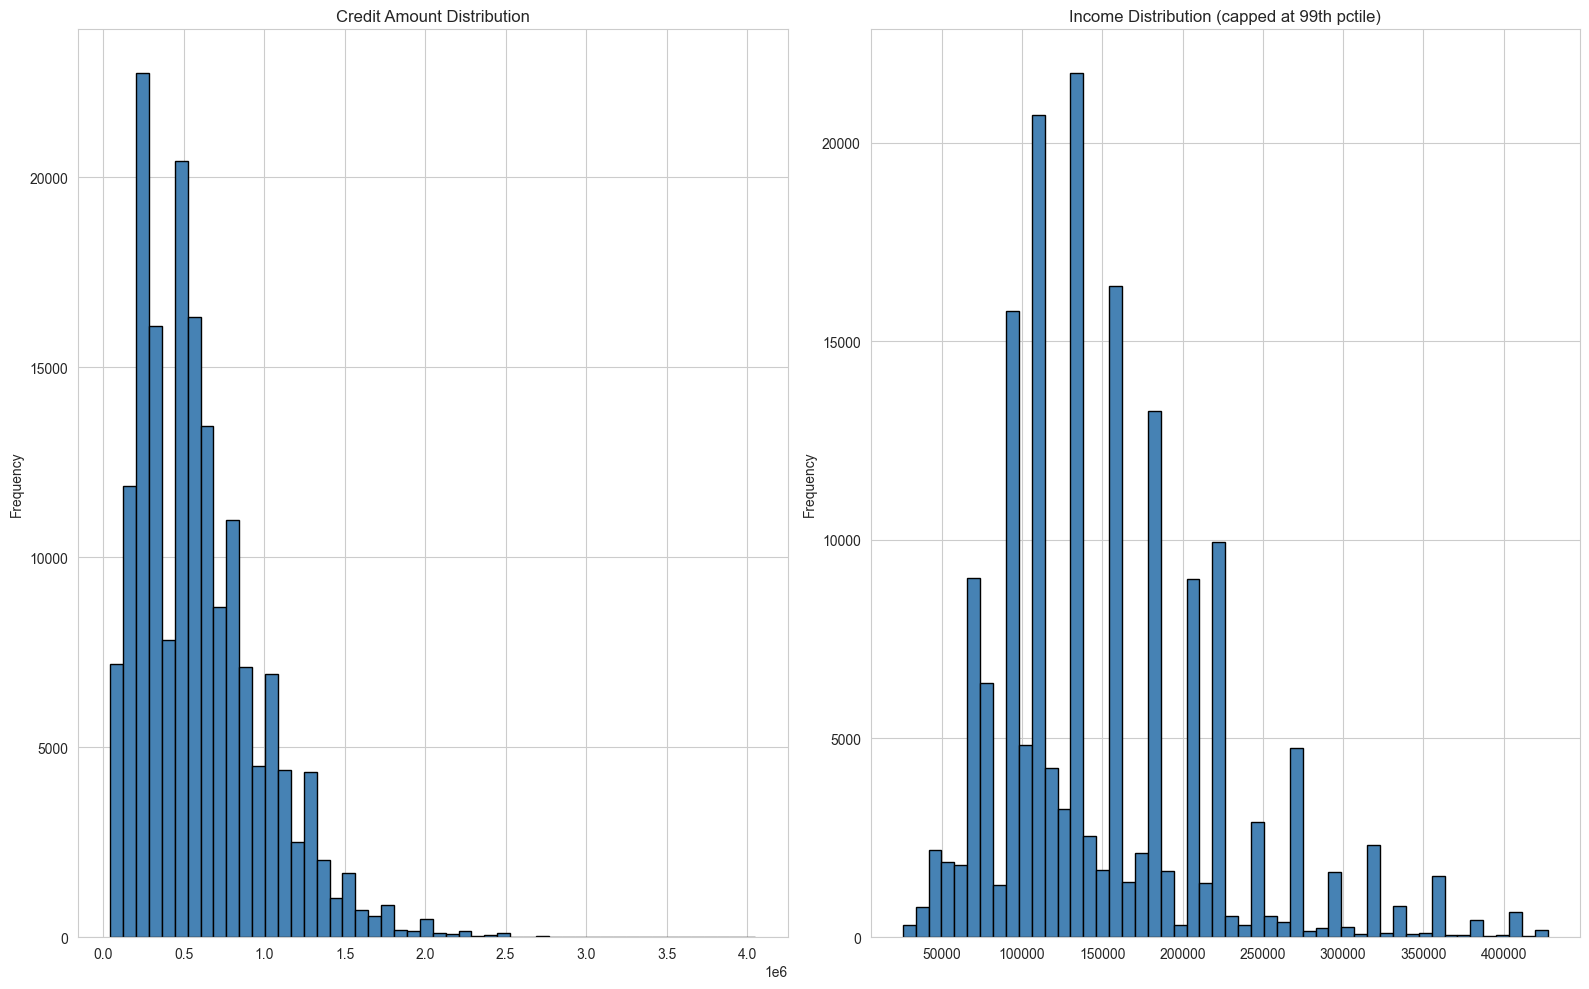

In [291]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Credit amount
group5['AMT_CREDIT'].plot(
    kind='hist', bins=50, ax=axes[0],
    color='steelblue', edgecolor='black'
)
axes[0].set_title('Credit Amount Distribution')

# Income (capped at 99th pctile for readability)
cap = group5['AMT_INCOME_TOTAL'].quantile(0.99)
group5.loc[group5['AMT_INCOME_TOTAL'] <= cap, 'AMT_INCOME_TOTAL'].plot(
    kind='hist', bins=50, ax=axes[1],
    color='steelblue', edgecolor='black'
)
axes[1].set_title('Income Distribution (capped at 99th pctile)')

plt.tight_layout()
plt.show()

In [292]:
group5.nunique().sort_values(ascending=True).head()

FLAG_DOCUMENT_10               1
FLAG_DOCUMENT_7                1
FLAG_DOCUMENT_12               1
FLAG_MOBIL                     1
LIVE_REGION_NOT_WORK_REGION    2
dtype: int64

In [293]:
##aggregate enquiry data into one column and drop the original columns
group5["TOTAL_ENQUIRIES"] = group5[[
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR"
]].sum(axis=1)

group5.drop(columns=[ "AMT_REQ_CREDIT_BUREAU_HOUR", 
                      "AMT_REQ_CREDIT_BUREAU_DAY", 
                      "AMT_REQ_CREDIT_BUREAU_WEEK", 
                      "AMT_REQ_CREDIT_BUREAU_MON", 
                      "AMT_REQ_CREDIT_BUREAU_QRT", 
                      "AMT_REQ_CREDIT_BUREAU_YEAR"], inplace=True)

##drop the columns with no variance (only 1 unique value)
group5.drop(columns=['FLAG_DOCUMENT_12','FLAG_DOCUMENT_7','FLAG_MOBIL','FLAG_DOCUMENT_10'], inplace=True)

# Calculate missing percentage for each column
missing_pct = group5.isnull().mean()

# Identify columns with more than 45% missing
cols_to_drop = missing_pct[missing_pct > 0.45].index.tolist()

print(f"Columns to drop ({len(cols_to_drop)}):")
print(cols_to_drop)

# Drop them
group5 = group5.drop(columns=cols_to_drop)
print(f"\nShape after dropping: {group5.shape}")

Columns to drop (48):
['EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTA

In [294]:
group5.loc[:, group5.isnull().sum() > 0].isnull().sum()

##need to find out what to do with the missing data at this level before merging

# AMT_ANNUITY            8
# NAME_TYPE_SUITE      534 - leave as missing, can use binning
# OCCUPATION_TYPE    59540 - leave as missing, unemployed or pensioners
# EMP_YEARS          36194 - leave as missing, unemployed or pensioners

AMT_ANNUITY            8
NAME_TYPE_SUITE      534
OCCUPATION_TYPE    59540
EMP_YEARS          36194
dtype: int64

In [295]:
# Calculate correlation of AMT_ANNUITY with all other numeric columns
correlations = group5.corr(numeric_only=True)['AMT_ANNUITY'].sort_values(ascending=False)

# Filter out AMT_ANNUITY itself and get the top match
# We use .index[1] because .index[0] will be 'AMT_ANNUITY' (correlation = 1.0)
best_feature = correlations.index[1]
best_corr_value = correlations.values[1]

print(f"The column most correlated with AMT_ANNUITY is: {best_feature}")
print(f"Correlation coefficient: {best_corr_value:.4f}")

The column most correlated with AMT_ANNUITY is: AMT_GOODS_PRICE
Correlation coefficient: 0.7658


In [296]:
# 1. Calculate the median ratio between Annuity and the best feature
# (Using median is safer than mean to avoid outlier distortion)
valid_data = group5[group5['AMT_ANNUITY'].notnull() & group5[best_feature].notnull()]
median_ratio = (valid_data['AMT_ANNUITY'] / valid_data[best_feature]).median()

print(f"Median ratio (Annuity / {best_feature}): {median_ratio:.4f}")

# 2. Identify rows where Annuity is missing but the anchor feature exists
mask = group5['AMT_ANNUITY'].isnull() & group5[best_feature].notnull()

# 3. Fill missing values using the ratio
group5.loc[mask, 'AMT_ANNUITY'] = group5.loc[mask, best_feature] * median_ratio

# 4. Final fallback: If both are missing, use the global median of AMT_ANNUITY
group5['AMT_ANNUITY'] = group5['AMT_ANNUITY'].fillna(group5['AMT_ANNUITY'].median())

print(f"Remaining NaNs in AMT_ANNUITY: {group5['AMT_ANNUITY'].isnull().sum()}")

Median ratio (Annuity / AMT_GOODS_PRICE): 0.0542
Remaining NaNs in AMT_ANNUITY: 0


In [297]:
# Categorical variables — distribution & bad-rate
cat_cols = group5.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}\n")

for col in cat_cols:
    vc = group5[col].value_counts(dropna=False)
    bad_rate = group5.groupby(col, dropna=False)['TARGET'].mean()
    summary = pd.DataFrame({
        'count': vc,
        'pct': (vc / len(group5) * 100).round(2),
        'bad_rate': bad_rate
    }).sort_values('count', ascending=False)
    summary['bad_rate'] = summary['bad_rate'].apply(
        lambda x: f"{x:.2%}" if pd.notna(x) else "N/A")
    print(f"--- {col}  ({group5[col].nunique()} unique, "
          f"{group5[col].isnull().sum()} nulls) ---")
    display(summary.head(10))
    print()

Categorical columns (9): ['FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']

--- FLAG_OWN_REALTY  (2 unique, 0 nulls) ---


,count,pct,bad_rate
FLAG_OWN_REALTY,,,
Y,118463,68.22,8.80%
N,55184,31.78,9.42%



--- NAME_TYPE_SUITE  (7 unique, 534 nulls) ---


,count,pct,bad_rate
NAME_TYPE_SUITE,,,
Unaccompanied,140604,80.97,9.15%
Family,22888,13.18,8.14%
"Spouse, partner",5754,3.31,8.99%
Children,2101,1.21,8.14%
Other_B,1108,0.64,10.83%
NaN,534,0.31,5.62%
Other_A,500,0.29,9.00%
Group of people,158,0.09,9.49%



--- NAME_INCOME_TYPE  (7 unique, 0 nulls) ---


...

,count,pct,bad_rate
OCCUPATION_TYPE,,,
NaN,59540,34.29,7.08%
Laborers,29739,17.13,12.32%
Sales staff,20474,11.79,10.59%
Core staff,16005,9.22,7.20%
Managers,8426,4.85,7.31%
High skill tech staff,5971,3.44,7.29%
Medicine staff,5852,3.37,7.16%
Accountants,5360,3.09,5.52%
Drivers,5060,2.91,14.76%



--- WEEKDAY_APPR_PROCESS_START  (7 unique, 0 nulls) ---


,count,pct,bad_rate
WEEKDAY_APPR_PROCESS_START,,,
TUESDAY,30757,17.71,9.26%
WEDNESDAY,29210,16.82,9.18%
MONDAY,28671,16.51,8.52%
FRIDAY,28355,16.33,9.18%
THURSDAY,28296,16.30,8.93%
SATURDAY,19273,11.10,8.89%
SUNDAY,9085,5.23,8.93%



--- ORGANIZATION_TYPE  (58 unique, 0 nulls) ---


,count,pct,bad_rate
ORGANIZATION_TYPE,,,
XNA,36194,20.84,5.92%
Business Entity Type 3,35048,20.18,10.82%
Self-employed,20917,12.05,11.36%
Other,9379,5.40,8.53%
Medicine,7253,4.18,7.18%
Government,6074,3.50,8.05%
School,5724,3.30,6.31%
Business Entity Type 2,5701,3.28,9.31%
Kindergarten,4824,2.78,7.86%


Shape: (1716428, 18)

Data types:
float64    8
int64      6
object     3
int32      1
Name: count, dtype: int64

Missing Values:


,dtype,null_count,null_pct,nunique
AMT_ANNUITY,float64,1226791,71.47,40321
AMT_CREDIT_MAX_OVERDUE,float64,1124488,65.51,68251
DAYS_ENDDATE_FACT,float64,633653,36.92,2917
AMT_CREDIT_SUM_LIMIT,float64,591780,34.48,51726
AMT_CREDIT_SUM_DEBT,float64,257669,15.01,226537
DAYS_CREDIT_ENDDATE,float64,105553,6.15,14096
SK_ID_CURR,int64,0,0.00,305811
DAYS_CREDIT_UPDATE,int64,0,0.00,2982
CREDIT_TYPE,object,0,0.00,15
AMT_CREDIT_SUM_OVERDUE,float64,0,0.00,1616


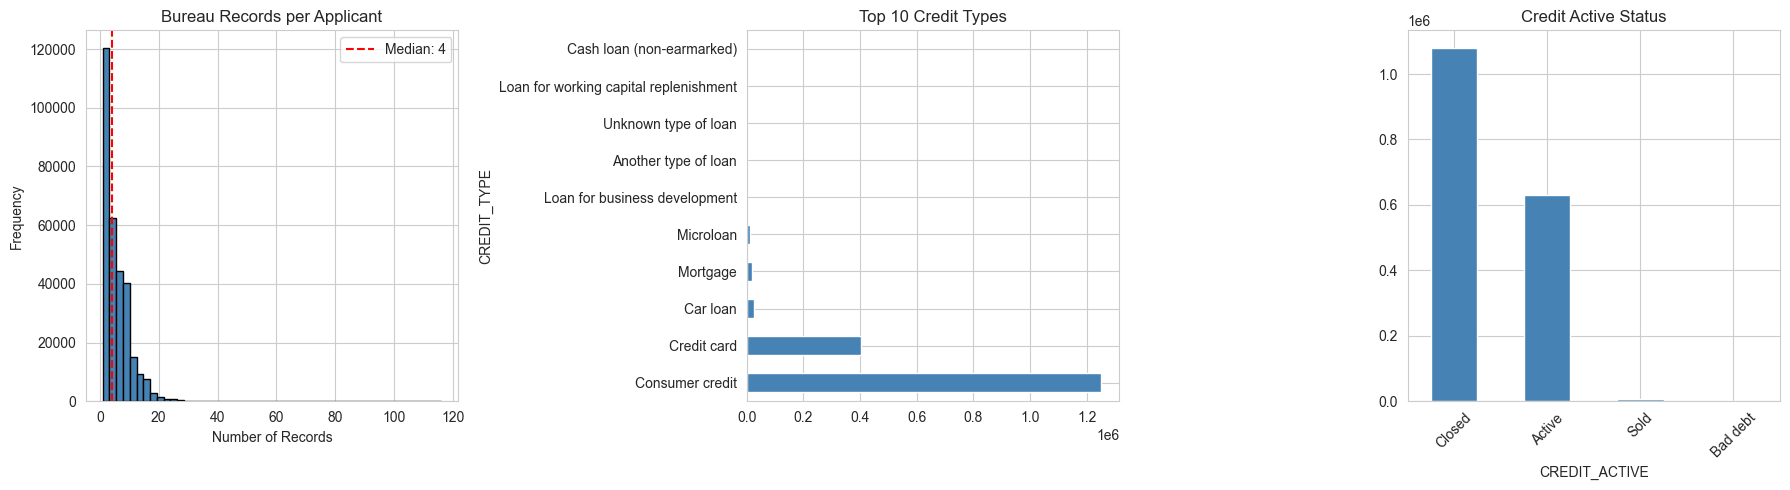


Records per applicant:
count   305811.00
mean         5.61
std          4.43
min          1.00
25%          2.00
50%          4.00
75%          8.00
max        116.00
dtype: float64

Bureau Numerical Summary:


,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,HAS_CAR_LOAN
count,1716428.00,1716428.00,1716428.00,1716428.00,1610875.00,1082775.00,591940.00,1716428.00,1716415.00,1458759.00,1124648.00,1716428.00,1716428.00,489637.00,1716428.00
mean,278214.93,5924434.49,-1142.11,0.82,510.52,-1017.44,3825.42,0.01,354994.59,137085.12,6229.51,37.91,-593.75,15712.76,0.02
std,102938.56,532265.73,795.16,36.54,4994.22,714.01,206031.61,0.10,1149811.34,677401.13,45032.03,5937.65,720.75,325826.95,0.13
min,100001.00,5000000.00,-2922.00,0.00,-42060.00,-42023.00,0.00,0.00,0.00,-4705600.32,-586406.11,0.00,-41947.00,0.00,0.00
25%,188866.75,5463953.75,-1666.00,0.00,-1138.00,-1489.00,0.00,0.00,51300.00,0.00,0.00,0.00,-908.00,0.00,0.00
50%,278055.00,5926303.50,-987.00,0.00,-330.00,-897.00,0.00,0.00,125518.50,0.00,0.00,0.00,-395.00,0.00,0.00
75%,367426.00,6385681.25,-474.00,0.00,474.00,-425.00,0.00,0.00,315000.00,40153.50,0.00,0.00,-33.00,13500.00,0.00
max,456255.00,6843457.00,0.00,2792.00,31199.00,0.00,115987185.00,9.00,585000000.00,170100000.00,4705600.32,3756681.00,372.00,118453423.50,1.00


In [298]:
# Bureau Data Overview
bureau_missing = pd.DataFrame({
    'dtype': bureau_data.dtypes,
    'null_count': bureau_data.isnull().sum(),
    'null_pct': (bureau_data.isnull().sum() / len(bureau_data) * 100).round(2),
    'nunique': bureau_data.nunique()
}).sort_values('null_pct', ascending=False)

print(f"Shape: {bureau_data.shape}")
print(f"\nData types:\n{bureau_data.dtypes.value_counts()}")
print(f"\nMissing Values:")
display(bureau_missing)

# Distributions
records_per_app = bureau_data.groupby('SK_ID_CURR').size()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

records_per_app.plot(kind='hist', bins=50, ax=axes[0],
                     color='steelblue', edgecolor='black')
axes[0].set_title('Bureau Records per Applicant')
axes[0].set_xlabel('Number of Records')
axes[0].axvline(records_per_app.median(), color='red', linestyle='--',
                label=f'Median: {records_per_app.median():.0f}')
axes[0].legend()

bureau_data['CREDIT_TYPE'].value_counts().head(10).plot(
    kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Credit Types')

bureau_data['CREDIT_ACTIVE'].value_counts().plot(
    kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Credit Active Status')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nRecords per applicant:\n{records_per_app.describe()}")
print(f"\nBureau Numerical Summary:")
display(bureau_data.describe())

In [299]:
bureau_data = bureau_data[bureau_data["CREDIT_CURRENCY"]=="currency 1"]

bureau_data.drop(columns=["CREDIT_CURRENCY"], inplace=True)

bureau_data.shape

(1715020, 17)

In [300]:
bureau_data['DAYS_CREDIT_ENDDATE'] = np.where(
    bureau_data['DAYS_CREDIT_ENDDATE'] < -16294,
    np.nan,
    bureau_data['DAYS_CREDIT_ENDDATE']
)
bureau_data['DAYS_ENDDATE_FACT'] = np.where(
    bureau_data['DAYS_ENDDATE_FACT'] < -42022,
    np.nan,
    bureau_data['DAYS_ENDDATE_FACT']
)
bureau_data['DAYS_CREDIT_UPDATE'] = np.where(
    bureau_data['DAYS_CREDIT_UPDATE'] < -41850,
    np.nan,
    bureau_data['DAYS_CREDIT_UPDATE']
)

##0.49% of AMT_CREDIT_SUM_DEBT values are below 0. This is likely due to overpayment or credit balance. Since we will be doing sums and averages later, we can ignore this for now and floor at 0 after aggregation.
##0.02% of AMT_CREDIT_SUM_LIMIT are below 0, which is likely data error. We can set these to NaN as well. we can change this later.
bureau_data['AMT_CREDIT_SUM_LIMIT'] = np.where(
    bureau_data['AMT_CREDIT_SUM_LIMIT'] < 0,
    np.nan,
    bureau_data['AMT_CREDIT_SUM_LIMIT']
)

In [301]:
bureau_data.describe()

,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,HAS_CAR_LOAN
count,1715020.00,1715020.00,1715020.00,1715020.00,1609421.00,1081563.00,591636.00,1715020.00,1715007.00,1457644.00,1123900.00,1715020.00,1714925.00,489225.00,1715020.00
mean,278212.44,5924437.04,-1141.33,0.82,515.03,-1016.90,3670.15,0.01,351179.44,136522.71,6218.16,37.94,-590.98,15124.36,0.02
std,102936.97,532263.58,794.79,36.56,4980.45,712.90,202847.62,0.10,1099877.10,663052.64,44675.68,5940.09,651.76,313476.10,0.13
min,100001.00,5000000.00,-2922.00,0.00,-5150.00,-3042.00,0.00,0.00,0.00,-4705600.32,0.00,0.00,-2917.00,0.00,0.00
25%,188865.00,5463951.75,-1664.00,0.00,-1137.00,-1488.00,0.00,0.00,51255.00,0.00,0.00,0.00,-907.00,0.00,0.00
50%,278050.50,5926325.50,-986.00,0.00,-329.00,-896.00,0.00,0.00,125224.11,0.00,0.00,0.00,-394.00,0.00,0.00
75%,367417.25,6385675.25,-474.00,0.00,475.00,-425.00,0.00,0.00,314550.00,40240.12,0.00,0.00,-33.00,13500.00,0.00
max,456255.00,6843457.00,0.00,2792.00,31199.00,0.00,115987185.00,9.00,585000000.00,170100000.00,4705600.32,3756681.00,372.00,118453423.50,1.00


In [302]:
# ── Binary flags before aggregation ──
bureau_data['BUREAU_IS_ACTIVE']   = (bureau_data['CREDIT_ACTIVE'] == 'Active').astype(int)
bureau_data['BUREAU_IS_CLOSED']   = (bureau_data['CREDIT_ACTIVE'] == 'Closed').astype(int)
bureau_data['BUREAU_IS_BAD_SOLD'] = (bureau_data['CREDIT_ACTIVE'].isin(['Sold', 'Bad debt'])).astype(int)

# ── Collapse rare credit types ──
top_types = ['Consumer credit', 'Credit card', 'Car loan', 'Mortgage', 'Microloan']
bureau_data['CREDIT_TYPE_GROUPED'] = bureau_data['CREDIT_TYPE'].apply(
    lambda x: x if x in top_types else 'Other'
)

# ── Main aggregation ──
bureau_agg = bureau_data.groupby('SK_ID_CURR').agg(
    # ── Record count ──
    BUREAU_RECORD_COUNT        = ('SK_ID_BUREAU', 'count'),

    # ── Credit active status ──
    BUREAU_ACTIVE_COUNT        = ('BUREAU_IS_ACTIVE', 'sum'),
    BUREAU_CLOSED_COUNT        = ('BUREAU_IS_CLOSED', 'sum'),
    BUREAU_BAD_SOLD_COUNT      = ('BUREAU_IS_BAD_SOLD', 'sum'),  # strong risk signal

    # ── Days credit (when credit was reported, negative = past) ──
    BUREAU_OLDEST_CREDIT       = ('DAYS_CREDIT', 'min'),   # most negative = oldest
    BUREAU_RECENT_CREDIT       = ('DAYS_CREDIT', 'max'),   # closest to 0 = most recent
    BUREAU_AVG_CREDIT_AGE      = ('DAYS_CREDIT', 'mean'),

    # ── Days overdue ──
    BUREAU_MAX_OVERDUE_DAYS    = ('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_MEAN_OVERDUE_DAYS   = ('CREDIT_DAY_OVERDUE', 'mean'),
    BUREAU_SUM_OVERDUE_DAYS    = ('CREDIT_DAY_OVERDUE', 'sum'),

    # ── Credit end date ──
    BUREAU_EARLIEST_ENDDATE    = ('DAYS_CREDIT_ENDDATE', 'min'),
    BUREAU_LATEST_ENDDATE      = ('DAYS_CREDIT_ENDDATE', 'max'),

    # ── Actual end date (only for closed credits) ──
    BUREAU_EARLIEST_CLOSED     = ('DAYS_ENDDATE_FACT', 'min'),
    BUREAU_LATEST_CLOSED       = ('DAYS_ENDDATE_FACT', 'max'),

    # ── Max overdue amount ever ──
    BUREAU_MAX_AMT_OVERDUE     = ('AMT_CREDIT_MAX_OVERDUE', 'max'),
    BUREAU_MEAN_AMT_OVERDUE    = ('AMT_CREDIT_MAX_OVERDUE', 'mean'),
    BUREAU_SUM_AMT_OVERDUE     = ('AMT_CREDIT_MAX_OVERDUE', 'sum'),

    # ── Credit prolongations ──
    BUREAU_TOTAL_PROLONGATIONS = ('CNT_CREDIT_PROLONG', 'sum'),
    BUREAU_MAX_PROLONGATIONS   = ('CNT_CREDIT_PROLONG', 'max'),

    # ── Total credit amount ──
    BUREAU_TOTAL_CREDIT        = ('AMT_CREDIT_SUM', 'sum'),
    BUREAU_MAX_CREDIT          = ('AMT_CREDIT_SUM', 'max'),
    BUREAU_MEAN_CREDIT         = ('AMT_CREDIT_SUM', 'mean'),

    # ── Outstanding debt ──
    BUREAU_TOTAL_DEBT          = ('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_MAX_DEBT            = ('AMT_CREDIT_SUM_DEBT', 'max'),
    BUREAU_MEAN_DEBT           = ('AMT_CREDIT_SUM_DEBT', 'mean'),

    # ── Credit limit ──
    BUREAU_TOTAL_LIMIT         = ('AMT_CREDIT_SUM_LIMIT', 'sum'),
    BUREAU_MAX_LIMIT           = ('AMT_CREDIT_SUM_LIMIT', 'max'),

    # ── Current overdue amount ──
    BUREAU_TOTAL_AMT_OVERDUE   = ('AMT_CREDIT_SUM_OVERDUE', 'sum'),
    BUREAU_MAX_AMT_OVERDUE_NOW = ('AMT_CREDIT_SUM_OVERDUE', 'max'),

    # ── Credit type diversity ──
    BUREAU_CREDIT_TYPE_COUNT   = ('CREDIT_TYPE_GROUPED', 'nunique'),

    # ── Days since last update ──
    BUREAU_LAST_UPDATE         = ('DAYS_CREDIT_UPDATE', 'max'),
    BUREAU_OLDEST_UPDATE       = ('DAYS_CREDIT_UPDATE', 'min'),

    # ── Annuity ──
    BUREAU_TOTAL_ANNUITY       = ('AMT_ANNUITY', 'sum'),
    BUREAU_MAX_ANNUITY         = ('AMT_ANNUITY', 'max'),
    BUREAU_MEAN_ANNUITY        = ('AMT_ANNUITY', 'mean'),
).reset_index()

# ── Credit type pivot (collapsed) ──
credit_type_pivot = bureau_data.groupby('SK_ID_CURR')['CREDIT_TYPE_GROUPED'] \
    .value_counts().unstack(fill_value=0)
credit_type_pivot.columns = [
    f'BUREAU_TYPE_{c.replace(" ", "_").upper()}'
    for c in credit_type_pivot.columns]

# ── Final merge ──
bureau_agg = bureau_agg \
    .merge(credit_type_pivot.reset_index(), on='SK_ID_CURR', how='left')
# All zero-fills
fill_zero = [
    'BUREAU_MAX_AMT_OVERDUE', 'BUREAU_MEAN_AMT_OVERDUE',
    'BUREAU_MAX_DEBT', 'BUREAU_MEAN_DEBT',
    'BUREAU_MAX_LIMIT', 'BUREAU_MAX_ANNUITY', 'BUREAU_MEAN_ANNUITY',
    'BUREAU_MAX_CREDIT', 'BUREAU_MEAN_CREDIT',
]
bureau_agg[fill_zero] = bureau_agg[fill_zero].fillna(0)

# Conditional — flag then fill
bureau_agg['HAS_NO_CLOSED_CREDIT'] = bureau_agg['BUREAU_EARLIEST_CLOSED'].isna().astype(int)
bureau_agg['HAS_NO_ENDDATE']        = bureau_agg['BUREAU_EARLIEST_ENDDATE'].isna().astype(int)

bureau_agg.drop("BUREAU_TYPE_CAR_LOAN", axis=1, inplace=True)
print(f"Bureau aggregated shape: {bureau_agg.shape}")
print(f"Columns: {bureau_agg.columns.tolist()}")

Bureau aggregated shape: (305773, 43)
Columns: ['SK_ID_CURR', 'BUREAU_RECORD_COUNT', 'BUREAU_ACTIVE_COUNT', 'BUREAU_CLOSED_COUNT', 'BUREAU_BAD_SOLD_COUNT', 'BUREAU_OLDEST_CREDIT', 'BUREAU_RECENT_CREDIT', 'BUREAU_AVG_CREDIT_AGE', 'BUREAU_MAX_OVERDUE_DAYS', 'BUREAU_MEAN_OVERDUE_DAYS', 'BUREAU_SUM_OVERDUE_DAYS', 'BUREAU_EARLIEST_ENDDATE', 'BUREAU_LATEST_ENDDATE', 'BUREAU_EARLIEST_CLOSED', 'BUREAU_LATEST_CLOSED', 'BUREAU_MAX_AMT_OVERDUE', 'BUREAU_MEAN_AMT_OVERDUE', 'BUREAU_SUM_AMT_OVERDUE', 'BUREAU_TOTAL_PROLONGATIONS', 'BUREAU_MAX_PROLONGATIONS', 'BUREAU_TOTAL_CREDIT', 'BUREAU_MAX_CREDIT', 'BUREAU_MEAN_CREDIT', 'BUREAU_TOTAL_DEBT', 'BUREAU_MAX_DEBT', 'BUREAU_MEAN_DEBT', 'BUREAU_TOTAL_LIMIT', 'BUREAU_MAX_LIMIT', 'BUREAU_TOTAL_AMT_OVERDUE', 'BUREAU_MAX_AMT_OVERDUE_NOW', 'BUREAU_CREDIT_TYPE_COUNT', 'BUREAU_LAST_UPDATE', 'BUREAU_OLDEST_UPDATE', 'BUREAU_TOTAL_ANNUITY', 'BUREAU_MAX_ANNUITY', 'BUREAU_MEAN_ANNUITY', 'BUREAU_TYPE_CONSUMER_CREDIT', 'BUREAU_TYPE_CREDIT_CARD', 'BUREAU_TYPE_MICROLOAN'

In [303]:
##create new features based on bureau data
# 1. Bureau Credit Utilisation  (outstanding debt / total credit limit)
#    Core credit-scoring signal — 90% utilisation >> 30% at same absolute debt
bureau_agg['BUREAU_DEBT_UTIL'] = (
    bureau_agg['BUREAU_TOTAL_DEBT'] / bureau_agg['BUREAU_TOTAL_LIMIT']
).clip(lower=0, upper=5)   # floor at 0 (debt already floored) + cap extreme outliers


# 2. Average Prolongations per Bureau Loan  (habitual extension frequency)
bureau_agg['BUREAU_AVG_PROLONGATIONS'] = (
    bureau_agg['BUREAU_TOTAL_PROLONGATIONS']
    / bureau_agg['BUREAU_RECORD_COUNT']
)

# 3. Bureau Active Rate  (fraction of credits still active)
#    RECORD_COUNT = ACTIVE + CLOSED + BAD_SOLD is a mathematical identity →
#    keeping all three causes VIF in the thousands. Convert to rate instead.
bureau_agg['BUREAU_ACTIVE_RATE'] = (
    bureau_agg['BUREAU_ACTIVE_COUNT']
    / bureau_agg['BUREAU_RECORD_COUNT']
)

# 4. Bureau Bad/Sold Rate  (fraction of credits written off or sold)
bureau_agg['BUREAU_BAD_SOLD_RATE'] = (
    bureau_agg['BUREAU_BAD_SOLD_COUNT']
    / bureau_agg['BUREAU_RECORD_COUNT']
)


In [304]:
merged_df = group5.merge(bureau_agg, on='SK_ID_CURR', how='left')

print(f"\nMerged DataFrame: {merged_df.shape}")
print(f"With bureau data:    {merged_df['BUREAU_RECORD_COUNT'].notna().sum():,}")
print(f"Without bureau data: {merged_df['BUREAU_RECORD_COUNT'].isna().sum():,}")


Merged DataFrame: (173647, 105)
With bureau data:    146,758
Without bureau data: 26,889


In [305]:
merged_missing = pd.DataFrame({
    'dtype': merged_df.dtypes,
    'null_count': merged_df.isnull().sum(),
    'null_pct': (merged_df.isnull().sum() / len(merged_df) * 100).round(2),
    'nunique': merged_df.nunique()
}).sort_values('null_pct', ascending=False)


print(f"\nData types:\n{merged_df.dtypes.value_counts()}")
print(f"\nMissing Values:")
pd.set_option('display.max_rows', None)
display(merged_missing[merged_missing["null_count"]>0].sort_values("null_count", ascending=False))



Data types:
float64    61
int64      35
object      9
Name: count, dtype: int64

Missing Values:


,dtype,null_count,null_pct,nunique
BUREAU_DEBT_UTIL,float64,68860,39.66,9396
OCCUPATION_TYPE,object,59540,34.29,18
BUREAU_LATEST_CLOSED,float64,45982,26.48,2771
BUREAU_EARLIEST_CLOSED,float64,45982,26.48,2892
EMP_YEARS,float64,36194,20.84,453
BUREAU_LATEST_ENDDATE,float64,28180,16.23,11346
BUREAU_EARLIEST_ENDDATE,float64,28180,16.23,5963
BUREAU_OLDEST_UPDATE,float64,26890,15.49,2887
BUREAU_LAST_UPDATE,float64,26890,15.49,2531
BUREAU_TYPE_CONSUMER_CREDIT,float64,26889,15.48,51


In [306]:
# Select numerical columns for VIF
vif_candidates = merged_df.select_dtypes(include='number').columns.tolist()
vif_candidates = [c for c in vif_candidates
                  if c not in ['SK_ID_CURR', 'TARGET']
                  and merged_df[c].nunique() > 1]

# Use top-30 by TARGET correlation (VIF is O(p²n))
target_corr_abs = merged_df[vif_candidates + ['TARGET']].corr()['TARGET'] \
    .drop('TARGET').abs().sort_values(ascending=False)
vif_candidates = target_corr_abs.head(30).index.tolist()
print(f"VIF on top 30 features (by |corr with TARGET|)")

# Sample for speed & standardise
sample = merged_df[vif_candidates].sample(
    min(10_000, len(merged_df)), random_state=42).dropna()
sample_std = (sample - sample.mean()) / sample.std()
sample_std = sample_std.dropna(axis=1)           # drop any all-NaN cols

vif_results = pd.DataFrame({
    'feature': sample_std.columns,
    'VIF': [variance_inflation_factor(sample_std.values, i)
            for i in range(sample_std.shape[1])]
}).sort_values('VIF', ascending=False)

print("\nVIF  (>5 = moderate,  >10 = severe multicollinearity)")
display(vif_results)

high_vif = vif_results[vif_results['VIF'] > 5]
print(f"\nFeatures with VIF > 5: {len(high_vif)}")
if len(high_vif) > 0:
    display(high_vif)

VIF on top 30 features (by |corr with TARGET|)

VIF  (>5 = moderate,  >10 = severe multicollinearity)


,feature,VIF
22,AMT_CREDIT,36.46
16,AMT_GOODS_PRICE,36.39
10,REGION_RATING_CLIENT_W_CITY,10.60
11,REGION_RATING_CLIENT,10.56
0,BUREAU_AVG_CREDIT_AGE,9.72
9,BUREAU_EARLIEST_CLOSED,8.50
4,BUREAU_OLDEST_CREDIT,8.48
7,REG_CITY_NOT_WORK_CITY,8.23
17,LIVE_CITY_NOT_WORK_CITY,6.56
5,BUREAU_ACTIVE_COUNT,4.58



Features with VIF > 5: 9


,feature,VIF
22,AMT_CREDIT,36.46
16,AMT_GOODS_PRICE,36.39
10,REGION_RATING_CLIENT_W_CITY,10.60
11,REGION_RATING_CLIENT,10.56
0,BUREAU_AVG_CREDIT_AGE,9.72
9,BUREAU_EARLIEST_CLOSED,8.50
4,BUREAU_OLDEST_CREDIT,8.48
7,REG_CITY_NOT_WORK_CITY,8.23
17,LIVE_CITY_NOT_WORK_CITY,6.56


In [307]:
# Correlation analysis on GROUP 5 data
num_cols = merged_df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'SK_ID_CURR']

corr_matrix = merged_df[num_cols].corr()

# 1) Correlation with TARGET
target_corr = corr_matrix['TARGET'].drop('TARGET').abs().sort_values(ascending=False)
print("Top 20 features correlated with TARGET:")
display(target_corr.head(20))

Top 20 features correlated with TARGET:


BUREAU_AVG_CREDIT_AGE         0.09
AGE_YEARS                     0.09
BUREAU_ACTIVE_RATE            0.08
EMP_YEARS                     0.08
BUREAU_OLDEST_CREDIT          0.08
BUREAU_ACTIVE_COUNT           0.07
BUREAU_OLDEST_UPDATE          0.07
REG_CITY_NOT_WORK_CITY        0.06
DAYS_LAST_PHONE_CHANGE        0.06
BUREAU_EARLIEST_CLOSED        0.06
REGION_RATING_CLIENT_W_CITY   0.06
REGION_RATING_CLIENT          0.06
DAYS_ID_PUBLISH               0.06
FLAG_EMP_PHONE                0.06
HAS_NO_CLOSED_CREDIT          0.05
BUREAU_RECENT_CREDIT          0.05
REG_CITY_NOT_LIVE_CITY        0.05
DAYS_REGISTRATION             0.05
AMT_GOODS_PRICE               0.04
LIVE_CITY_NOT_WORK_CITY       0.04
Name: TARGET, dtype: float64

In [308]:
# 2) Highly-correlated feature pairs (|r| > 0.75)
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [
    (col, idx, upper_tri.loc[idx, col])
    for col in upper_tri.columns for idx in upper_tri.index
    if abs(upper_tri.loc[idx, col]) > 0.73
]
high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"\nHighly correlated feature pairs (|r| > 0.75): {len(high_corr_pairs)}")
high_corr_df = pd.DataFrame(
    high_corr_pairs, columns=['Feature_1', 'Feature_2', 'Correlation'])
display(high_corr_df)


Highly correlated feature pairs (|r| > 0.75): 36


,Feature_1,Feature_2,Correlation
0,BUREAU_SUM_AMT_OVERDUE,BUREAU_MAX_AMT_OVERDUE,1.00
1,OBS_60_CNT_SOCIAL_CIRCLE,OBS_30_CNT_SOCIAL_CIRCLE,1.00
2,BUREAU_MAX_PROLONGATIONS,BUREAU_TOTAL_PROLONGATIONS,0.99
3,BUREAU_SUM_OVERDUE_DAYS,BUREAU_MAX_OVERDUE_DAYS,0.99
4,AMT_GOODS_PRICE,AMT_CREDIT,0.99
5,BUREAU_MEAN_AMT_OVERDUE,BUREAU_MAX_AMT_OVERDUE,0.98
6,BUREAU_SUM_AMT_OVERDUE,BUREAU_MEAN_AMT_OVERDUE,0.98
7,BUREAU_MAX_DEBT,BUREAU_TOTAL_DEBT,0.97
8,BUREAU_MAX_LIMIT,BUREAU_TOTAL_LIMIT,0.95
9,BUREAU_MAX_AMT_OVERDUE_NOW,BUREAU_TOTAL_AMT_OVERDUE,0.95


In [309]:
list(high_corr_df["Feature_1"]) + list(high_corr_df["Feature_2"])

['BUREAU_SUM_AMT_OVERDUE',
 'OBS_60_CNT_SOCIAL_CIRCLE',
 'BUREAU_MAX_PROLONGATIONS',
 'BUREAU_SUM_OVERDUE_DAYS',
 'AMT_GOODS_PRICE',
 'BUREAU_MEAN_AMT_OVERDUE',
 'BUREAU_SUM_AMT_OVERDUE',
 'BUREAU_MAX_DEBT',
 'BUREAU_MAX_LIMIT',
 'BUREAU_MAX_AMT_OVERDUE_NOW',
 'REGION_RATING_CLIENT_W_CITY',
 'BUREAU_TYPE_CONSUMER_CREDIT',
 'BUREAU_MAX_ANNUITY',
 'BUREAU_CLOSED_COUNT',
 'BUREAU_TYPE_CONSUMER_CREDIT',
 'BUREAU_EARLIEST_CLOSED',
 'BUREAU_OLDEST_UPDATE',
 'BUREAU_MAX_CREDIT',
 'CNT_FAM_MEMBERS',
 'DEF_60_CNT_SOCIAL_CIRCLE',
 'LIVE_REGION_NOT_WORK_REGION',
 'BUREAU_OLDEST_UPDATE',
 'LIVE_CITY_NOT_WORK_CITY',
 'BUREAU_AVG_CREDIT_AGE',
 'BUREAU_MEAN_ANNUITY',
 'BUREAU_MEAN_CREDIT',
 'AMT_GOODS_PRICE',
 'BUREAU_MEAN_OVERDUE_DAYS',
 'AMT_ANNUITY',
 'BUREAU_MAX_DEBT',
 'BUREAU_SUM_OVERDUE_DAYS',
 'BUREAU_MEAN_DEBT',
 'BUREAU_MEAN_ANNUITY',
 'BUREAU_LAST_UPDATE',
 'FLAG_DOCUMENT_6',
 'BUREAU_TOTAL_DEBT',
 'BUREAU_MAX_AMT_OVERDUE',
 'OBS_30_CNT_SOCIAL_CIRCLE',
 'BUREAU_TOTAL_PROLONGATIONS',
 'BURE

In [310]:


# 1. Feature Selection & Data Preparation
# Exclude identifiers and the target itself
target = 'TARGET'
feature_cols = list(set(list(high_corr_df["Feature_1"]) + list(high_corr_df["Feature_2"])))

# Prepare data: ensure 'Missing' is treated as NaN for scorecardpy
df_processed = merged_df[feature_cols + [target]].copy()
df_processed = df_processed.replace('Missing', np.nan)

# Ensure target is numeric 0/1
df_processed[target] = pd.to_numeric(df_processed[target], errors='coerce')
df_processed = df_processed.dropna(subset=[target])
df_processed[target] = df_processed[target].astype(int)

# 2. Remove datetime / date-like columns manually
# This avoids the scorecardpy-pandas compatibility issue in check_datetime_cols()
datetime_cols = df_processed.select_dtypes(
    include=['datetime64[ns]', 'datetime64[ns, UTC]', 'datetimetz']
).columns.tolist()

# Also detect object columns that are strongly date-like
for col in df_processed.select_dtypes(include='object').columns:
    if col == target:
        continue

    sample = df_processed[col].dropna().astype(str).head(200)
    if len(sample) == 0:
        continue

    parsed = pd.to_datetime(sample, errors='coerce')
    if parsed.notna().mean() > 0.9:
        datetime_cols.append(col)

datetime_cols = sorted(set(datetime_cols))
if datetime_cols:
    print("Dropping datetime/date-like columns:")
    print(datetime_cols)
    df_processed = df_processed.drop(columns=datetime_cols)

# 3. Remove constant columns
feature_only_cols = [c for c in df_processed.columns if c != target]
const_cols = [c for c in feature_only_cols if df_processed[c].nunique(dropna=False) <= 1]

if const_cols:
    print("\nDropping constant columns:")
    print(const_cols)
    df_processed = df_processed.drop(columns=const_cols)

# 4. Remove very high-cardinality object columns (often IDs / free text)
feature_only_cols = [c for c in df_processed.columns if c != target]
high_card_obj_cols = [
    c for c in feature_only_cols
    if df_processed[c].dtype == 'object' and df_processed[c].nunique(dropna=False) > 100
]

if high_card_obj_cols:
    print("\nDropping high-cardinality object columns:")
    print(high_card_obj_cols)
    df_processed = df_processed.drop(columns=high_card_obj_cols)

# 5. Target Distribution Check
goods = (df_processed[target] == 0).sum()
bads = (df_processed[target] == 1).sum()

print("\nDataset Summary:")
print(f"  - Goods: {goods:,} | Bads: {bads:,} | Bad Rate: {bads / len(df_processed):.2%}")

# 6. Perform Fine Classing (WOE Binning)
print("\n" + "=" * 50)
print("PERFORMING FINE CLASSING (Minimum 10 Bins)")
print("=" * 50)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    # IMPORTANT:
    # ignore_datetime_cols=False prevents scorecardpy from calling its internal
    # datetime checker that can fail with newer pandas versions.
    bins = sc.woebin(
        df_processed,
        y=target,
        min_num_bins=10,        # Force fine granularity
        stop_limit=0.0001,      # Smallest IV gain to keep splitting
        count_distr_limit=0.02, # Allow bins as small as 2% of total
        bin_num_limit=50,       # Max upper limit
        positive='bad|1',       # Ensure 1 is treated as the bad/default event
        ignore_datetime_cols=False,
        check_cate_num=False
    )

# 7. Extract IV Summary
# scorecardpy stores total IV for each variable within each variable's binning dataframe
iv_list = []
for var, df_bin in bins.items():
    if df_bin is not None and not df_bin.empty:
        iv_val = df_bin['total_iv'].iloc[0]
        iv_list.append({
            'Variable': var,
            'IV': iv_val,
            'Bins': len(df_bin)
        })

iv_df = pd.DataFrame(iv_list).sort_values('IV', ascending=False).reset_index(drop=True)

print("\nVariable IV Summary:")
display(iv_df.head(30))


Dataset Summary:
  - Goods: 158,018 | Bads: 15,629 | Bad Rate: 9.00%

PERFORMING FINE CLASSING (Minimum 10 Bins)
[INFO] creating woe binning ...
Binning on 173647 rows and 48 columns in 00:01:09

Variable IV Summary:


,Variable,IV,Bins
0,BUREAU_AVG_CREDIT_AGE,0.13,22
1,BUREAU_OLDEST_CREDIT,0.08,25
2,BUREAU_RECENT_CREDIT,0.08,19
3,BUREAU_EARLIEST_CLOSED,0.07,25
4,BUREAU_OLDEST_UPDATE,0.07,22
5,AMT_GOODS_PRICE,0.06,15
6,AMT_CREDIT,0.06,23
7,BUREAU_MEAN_DEBT,0.06,14
8,BUREAU_CLOSED_COUNT,0.05,12
9,BUREAU_LAST_UPDATE,0.05,13


In [311]:
##create new features based on domain knowledge and correlation analysis
merged_df['LTV_RATIO'] = merged_df['AMT_CREDIT'] / merged_df['AMT_GOODS_PRICE']

# 1. Annuity-to-Income Ratio  (affordability — primary default driver)
merged_df['ANNUITY_INCOME_RATIO'] = merged_df['AMT_ANNUITY'] / merged_df['AMT_INCOME_TOTAL'] ##not very correlated

# 2. Debt-to-Annuity  (implied loan tenure in months)
merged_df['DEBT_TO_ANNUITY'] = merged_df['AMT_CREDIT'] / merged_df['AMT_ANNUITY'] 

# Total Debt Service Ratio  (all bureau repayments + new loan vs income)
# merged_df['TOTAL_DSR'] = (
#     merged_df['BUREAU_TOTAL_ANNUITY'].fillna(0) + merged_df['AMT_ANNUITY']
# ) / merged_df['AMT_INCOME_TOTAL']
#commented out because near 0 IV

# 3. Social-Circle Default Rate — 60 DPD threshold
#    OBS_30/OBS_60 are DPD severity thresholds (30+ and 60+ days past due),
#    NOT time windows. r=1.00 between OBS_30 and OBS_60 is because they measure
#    the same social circle size; only the default threshold differs.
#    DEF_60 < DEF_30 is expected (stricter threshold = fewer defaults).
merged_df['DEF_RATE_60'] = (
    merged_df['DEF_60_CNT_SOCIAL_CIRCLE']
    / merged_df['OBS_60_CNT_SOCIAL_CIRCLE'].replace(0, np.nan)
).fillna(0)

# 4. Social-Circle Default Rate — 30 DPD threshold
#    DEF_30 and DEF_60 have r=0.86 (not 1.00), so the 30 DPD rate carries
#    ~26% independent signal that would otherwise be discarded.
# merged_df['DEF_RATE_30'] = (
#     merged_df['DEF_30_CNT_SOCIAL_CIRCLE']
#     / merged_df['OBS_30_CNT_SOCIAL_CIRCLE'].replace(0, np.nan)
# ).fillna(0) 
#commented out because lower IV

## 5. Bureau Credit Card Rate  (fraction of bureau credits that are credit cards)
merged_df['BUREAU_CONSUMER_CREDIT_RATE'] = (
    merged_df['BUREAU_TYPE_CONSUMER_CREDIT'] / merged_df['BUREAU_RECORD_COUNT']
)


In [312]:
features_to_drop_after_vif= []

In [313]:
##0th pair multicollinearity - BUREAU_SUM_AMOUNT_OVERDUE vs BUREAU_MAX_AMT_OVERDUE. retain max amount overdue since it has higher iv

features_to_drop_after_vif.append("BUREAU_SUM_OVERDUE_DAYS")

#first pair - OBS_60_CNT_SOCIAL_CIRCLE	vs OBS_30_CNT_SOCIAL_CIRCLE. drop both, replace with def_60 and def_30

features_to_drop_after_vif.append("OBS_60_CNT_SOCIAL_CIRCLE")
features_to_drop_after_vif.append("OBS_30_CNT_SOCIAL_CIRCLE")

#second pair -BUREAU_MAX_PROLONGATIONS	vs BUREAU_TOTAL_PROLONGATIONS. BUREAU_AVG_PROLONGATIONS takes into account total_prolongations

features_to_drop_after_vif.append("BUREAU_TOTAL_PROLONGATIONS")

##third pair - BUREAU_SUM_OVERDUE_DAYS	BUREAU_MAX_OVERDUE_DAYS - drop sum daus

features_to_drop_after_vif.append("BUREAU_SUM_OVERDUE_DAYS")

##fourth pair - AMT_GOODS_PRICE vs AMT_CREDIT. handled under LTV ratio. drop both columns

features_to_drop_after_vif.append("AMT_GOODS_PRICE")
features_to_drop_after_vif.append("AMT_CREDIT")

#fifth pair - BUREAU_MEAN_AMT_OVERDUE	BUREAU_MAX_AMT_OVERDUE - r≈1.0 with MAX; MAX captures worst case. keep only max

features_to_drop_after_vif.append("BUREAU_MEAN_AMT_OVERDUE")

#sixth pair - BUREAU_SUM_AMT_OVERDUE	BUREAU_MEAN_AMT_OVERDUE - already keeping max for this aggregation

features_to_drop_after_vif.append("BUREAU_SUM_AMT_OVERDUE")

#seventh pair - BUREAU_MAX_DEBT	BUREAU_TOTAL_DEBT. keep only mean debt.

features_to_drop_after_vif.append("BUREAU_MAX_DEBT")
features_to_drop_after_vif.append("BUREAU_TOTAL_DEBT")

#eighth pair - BUREAU_MAX_LIMIT	BUREAU_TOTAL_LIMIT - keep total, higher iv

features_to_drop_after_vif.append("BUREAU_MAX_LIMIT")

#ninth pair - BUREAU_MAX_AMT_OVERDUE_NOW	BUREAU_TOTAL_AMT_OVERDUE - drop max_amount_overdue_now, keep total amount overdue, higher ic

features_to_drop_after_vif.append("BUREAU_MAX_AMT_OVERDUE_NOW")

#tenth pair - REGION_RATING_CLIENT_W_CITY	REGION_RATING_CLIENT - keep city version, higher iv

features_to_drop_after_vif.append("REGION_RATING_CLIENT")

#11th pair - BUREAU_TYPE_CONSUMER_CREDIT	BUREAU_RECORD_COUNT - circular math. change consumer credit to consumer rate and drop consumer credit

features_to_drop_after_vif.append("BUREAU_TYPE_CONSUMER_CREDIT")

#12th pair - BUREAU_MAX_ANNUITY	BUREAU_TOTAL_ANNUITY keep only total annuity

features_to_drop_after_vif.append("BUREAU_MAX_ANNUITY")

# 13th pair - BUREAU_CLOSED_COUNT	BUREAU_RECORD_COUNT - circular math, drop closed count to prevent summing together, drop the other 2 counts, already included in active and bad/sold rate

features_to_drop_after_vif.append("BUREAU_CLOSED_COUNT")
features_to_drop_after_vif.append('BUREAU_BAD_SOLD_COUNT')
features_to_drop_after_vif.append("BUREAU_ACTIVE_COUNT")

#14th pair - BUREAU_TYPE_CONSUMER_CREDIT	BUREAU_CLOSED_COUNT - settled above

##15h pair - BUREAU_EARLIEST_CLOSED	BUREAU_OLDEST_CREDIT - drop both keep only average age

features_to_drop_after_vif.append("BUREAU_EARLIEST_CLOSED")
features_to_drop_after_vif.append("BUREAU_OLDEST_CREDIT")

##16th pair - BUREAU_OLDEST_UPDATE	BUREAU_EARLIEST_CLOSED - settled by dropping earliest closed

##17th pair - BUREAU_MAX_CREDIT	BUREAU_TOTAL_CREDIT - keep max (slightly different)

features_to_drop_after_vif.append("BUREAU_TOTAL_CREDIT")

##18th pair - CNT_FAM_MEMBERS	CNT_CHILDREN - keep only children, higher iv

features_to_drop_after_vif.append("CNT_FAM_MEMBERS")


##19th pair - DEF_60_CNT_SOCIAL_CIRCLE	DEF_30_CNT_SOCIAL_CIRCLE - settled above

features_to_drop_after_vif.append("DEF_60_CNT_SOCIAL_CIRCLE")
features_to_drop_after_vif.append("DEF_30_CNT_SOCIAL_CIRCLE")

##20th pair - LIVE_REGION_NOT_WORK_REGION	REG_REGION_NOT_WORK_REGION - reg higher

features_to_drop_after_vif.append("LIVE_REGION_NOT_WORK_REGION")

#21st pair - BUREAU_OLDEST_UPDATE	BUREAU_OLDEST_CREDIT - settled by dropping oldest credit

##22nd pair - LIVE_CITY_NOT_WORK_CITY	REG_CITY_NOT_WORK_CITY - keep reg, higher iv

features_to_drop_after_vif.append("LIVE_CITY_NOT_WORK_CITY")

##23rd pair - BUREAU_AVG_CREDIT_AGE	BUREAU_OLDEST_CREDIT - settled by dropping oldest credit

##24th pair - BUREAU_MEAN_ANNUITY	BUREAU_MAX_ANNUITY - dropped max annuity

##25th pair -  BUREAU_MEAN_CREDIT	BUREAU_MAX_CREDIT - keep max

features_to_drop_after_vif.append("BUREAU_MEAN_CREDIT")

##26th pair - AMT_GOODS_PRICE	AMT_ANNUITY - dropped goods price, annuity is more directly related to repayment ability

##27th pair - BUREAU_MEAN_OVERDUE_DAYS	BUREAU_MAX_OVERDUE_DAYS - drop max

features_to_drop_after_vif.append("BUREAU_MAX_OVERDUE_DAYS")

##28th pair AMT_ANNUITY	AMT_CREDIT - dropped credit already

##29th pair - BUREAU_MAX_DEBT	BUREAU_MAX_CREDIT - dropped max debt already

##30th pair - BUREAU_SUM_OVERDUE_DAYS	BUREAU_MEAN_OVERDUE_DAYS - dropped sum overdue days already

## 31st pair - BUREAU_MEAN_DEBT	BUREAU_MAX_DEBT - dropped max debt already

##32nd pair - BUREAU_MEAN_ANNUITY	BUREAU_TOTAL_ANNUITY - keep only total

features_to_drop_after_vif.append("BUREAU_MEAN_ANNUITY")

##33rd pair - BUREAU_LAST_UPDATE	BUREAU_RECENT_CREDIT - drop last update

features_to_drop_after_vif.append("BUREAU_LAST_UPDATE")


In [314]:
merged_df_reduced = merged_df.drop(columns=features_to_drop_after_vif)
print(f"Shape after dropping high-VIF features: {merged_df_reduced.shape}")

Shape after dropping high-VIF features: (173647, 80)


In [315]:
# Select numerical columns for VIF
vif_candidates = merged_df_reduced.select_dtypes(include='number').columns.tolist()
vif_candidates = [c for c in vif_candidates
                  if c not in ['SK_ID_CURR', 'TARGET']
                  and merged_df_reduced[c].nunique() > 1]

# Use top-30 by TARGET correlation (VIF is O(p²n))
target_corr_abs = merged_df_reduced[vif_candidates + ['TARGET']].corr()['TARGET'] \
    .drop('TARGET').abs().sort_values(ascending=False)
vif_candidates = target_corr_abs.head(30).index.tolist()
print(f"VIF on top 30 features (by |corr with TARGET|)")

# Sample for speed & standardise
sample = merged_df_reduced[vif_candidates].sample(
    min(10_000, len(merged_df_reduced)), random_state=42).dropna()
sample_std = (sample - sample.mean()) / sample.std()
sample_std = sample_std.dropna(axis=1)           # drop any all-NaN cols

vif_results = pd.DataFrame({
    'feature': sample_std.columns,
    'VIF': [variance_inflation_factor(sample_std.values, i)
            for i in range(sample_std.shape[1])]
}).sort_values('VIF', ascending=False)

print("\nVIF  (>5 = moderate,  >10 = severe multicollinearity)")
display(vif_results)

high_vif = vif_results[vif_results['VIF'] > 5]
print(f"\nFeatures with VIF > 5: {len(high_vif)}")
if len(high_vif) > 0:
    display(high_vif)

VIF on top 30 features (by |corr with TARGET|)

VIF  (>5 = moderate,  >10 = severe multicollinearity)


,feature,VIF
0,BUREAU_AVG_CREDIT_AGE,3.99
2,BUREAU_ACTIVE_RATE,3.31
4,BUREAU_OLDEST_UPDATE,3.19
10,HAS_NO_CLOSED_CREDIT,2.73
17,BUREAU_CONSUMER_CREDIT_RATE,2.03
20,BUREAU_TYPE_CREDIT_CARD,1.99
11,BUREAU_RECENT_CREDIT,1.85
14,BUREAU_EARLIEST_ENDDATE,1.53
1,AGE_YEARS,1.49
8,REGION_RATING_CLIENT_W_CITY,1.45



Features with VIF > 5: 0


In [316]:
num_cols = merged_df_reduced.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'SK_ID_CURR']

corr_matrix_new = merged_df_reduced[num_cols].corr()

# 1) Correlation with TARGET
target_corr_abs = corr_matrix_new['TARGET'].drop('TARGET').abs().sort_values(ascending=False)
print("Top 20 features correlated with TARGET:")
display(target_corr_abs.head(20))

# 2) Highly-correlated feature pairs (|r| > 0.75)
upper_tri_new = corr_matrix_new.where(
    np.triu(np.ones(corr_matrix_new.shape), k=1).astype(bool))
high_corr_pairs_new = [
    (col, idx, upper_tri_new.loc[idx, col])
    for col in upper_tri_new.columns for idx in upper_tri_new.index
    if abs(upper_tri_new.loc[idx, col]) > 0.75
]
high_corr_pairs_new.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"\nHighly correlated feature pairs (|r| > 0.75): {len(high_corr_pairs_new)}")
high_corr_df_new = pd.DataFrame(
    high_corr_pairs_new, columns=['Feature_1', 'Feature_2', 'Correlation'])
display(high_corr_df_new.head(30))

Top 20 features correlated with TARGET:


BUREAU_AVG_CREDIT_AGE         0.09
AGE_YEARS                     0.09
BUREAU_ACTIVE_RATE            0.08
EMP_YEARS                     0.08
BUREAU_OLDEST_UPDATE          0.07
LTV_RATIO                     0.06
REG_CITY_NOT_WORK_CITY        0.06
DAYS_LAST_PHONE_CHANGE        0.06
REGION_RATING_CLIENT_W_CITY   0.06
DAYS_ID_PUBLISH               0.06
FLAG_EMP_PHONE                0.06
HAS_NO_CLOSED_CREDIT          0.05
BUREAU_RECENT_CREDIT          0.05
REG_CITY_NOT_LIVE_CITY        0.05
DAYS_REGISTRATION             0.05
BUREAU_EARLIEST_ENDDATE       0.04
BUREAU_LATEST_ENDDATE         0.04
DEBT_TO_ANNUITY               0.04
BUREAU_CONSUMER_CREDIT_RATE   0.04
FLAG_DOCUMENT_6               0.04
Name: TARGET, dtype: float64


Highly correlated feature pairs (|r| > 0.75): 0


,Feature_1,Feature_2,Correlation


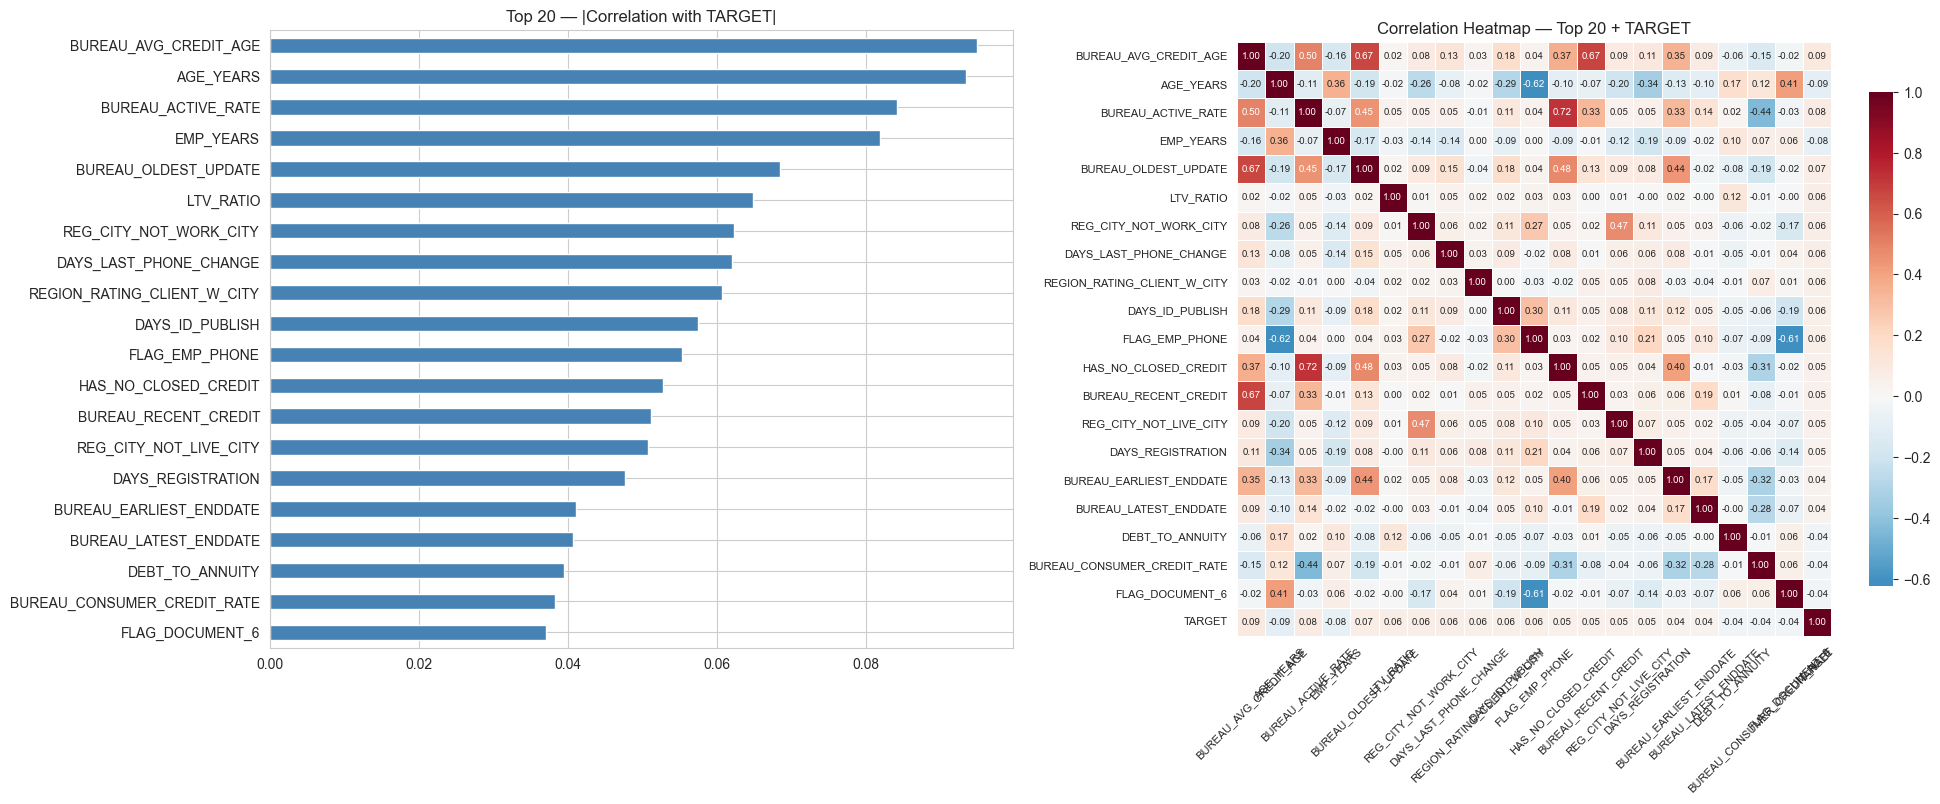

In [317]:
# Heatmap — top-20 TARGET-correlated features
top20 = target_corr_abs.head(20).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Bar chart
target_corr_abs.head(20).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 — |Correlation with TARGET|')
axes[0].invert_yaxis()

# Heatmap
sns.heatmap(merged_df_reduced[top20 + ['TARGET']].corr(),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], square=True, linewidths=0.5,
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlation Heatmap — Top 20 + TARGET')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

Columns with outliers: 16 / 28


,column,total,outlier_count,outlier_pct,lower_bound,upper_bound,min,max
17,BUREAU_MAX_AMT_OVERDUE,146758,35414,24.13,-270.00,360.00,0.00,94812246.00
15,BUREAU_LATEST_ENDDATE,145467,23827,16.38,-4578.00,6300.00,-2858.00,31199.00
22,BUREAU_DEBT_UTIL,104787,12092,11.54,5.00,5.00,0.00,5.00
19,BUREAU_MEAN_DEBT,146758,7183,4.89,-343910.67,458547.56,-684441.18,33902743.50
18,BUREAU_MAX_CREDIT,146758,7145,4.87,-1590932.25,2488743.00,0.00,135000000.00
12,BUREAU_RECENT_CREDIT,146758,4900,3.34,-2087.00,1322.00,-2922.00,0.00
9,EMP_YEARS,137453,2255,1.64,-18.30,29.30,0.00,46.10
1,AMT_INCOME_TOTAL,173647,1805,1.04,-126000.00,409500.00,25650.00,117000000.00
14,BUREAU_EARLIEST_ENDDATE,145467,1495,1.03,-7215.00,4643.00,-4736.00,31198.00
16,BUREAU_LATEST_CLOSED,127665,1102,0.86,-2461.00,1578.00,-2887.00,0.00


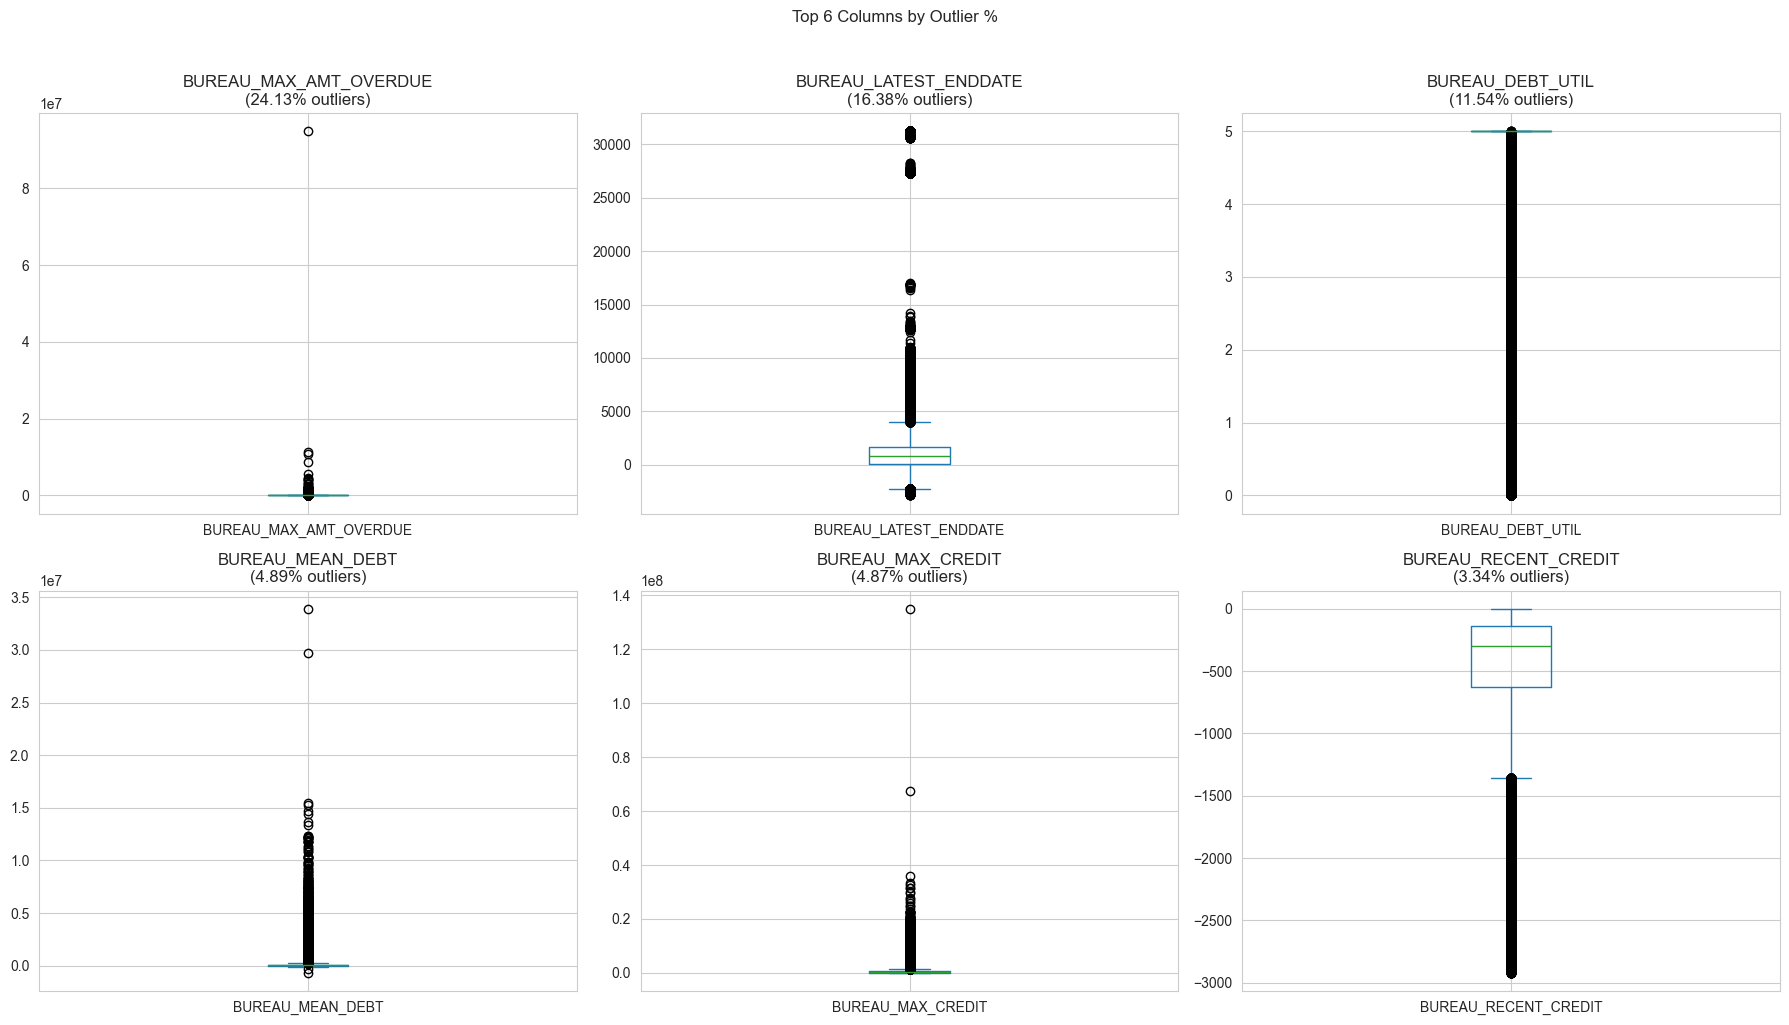


=== PROPOSED OUTLIER TREATMENT ===
Valid outliers (domain-expected extreme values):
  - AMT_INCOME_TOTAL: high incomes are valid → cap at 99th pctile
  - DAYS_EMPLOYED: 365243 placeholder already replaced with NaN
  - CNT_CHILDREN: large families valid → cap at 5+
Invalid outliers (likely data errors):
  - Negative values in amount fields → flag for review
  - Illogical DAYS values → review and treat


In [318]:
# Outlier detection — IQR method
num_cols_eda = merged_df_reduced.select_dtypes(include='number').columns.tolist()
# Skip zero-inflated columns from outlier capping
# A column is zero-inflated if its 75th percentile is 0
zero_inflated = [col for col in num_cols_eda 
                 if merged_df_reduced[col].quantile(0.75) == 0]
num_cols_eda = [c for c in num_cols_eda 
                if c not in ['SK_ID_CURR', 'TARGET']
                and c not in zero_inflated
                and merged_df_reduced[c].nunique() > 10]

outlier_rows = []
for col in num_cols_eda:
    data = merged_df_reduced[col].dropna()
    if len(data) == 0:
        continue
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR
    n_out = ((data < lower) | (data > upper)).sum()
    outlier_rows.append({
        'column': col,
        'total': len(data),
        'outlier_count': n_out,
        'outlier_pct': round(n_out / len(data) * 100, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'min': round(data.min(), 2),
        'max': round(data.max(), 2),
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values('outlier_pct', ascending=False)
print(f"Columns with outliers: "
      f"{(outlier_df['outlier_count'] > 0).sum()} / {len(outlier_df)}")
display(outlier_df.head(30))

# Box-plots for top-6 outlier columns
top6 = outlier_df.head(6)['column'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(top6):
    ax = axes[i // 3, i % 3]
    merged_df_reduced[col].dropna().plot(kind='box', ax=ax)
    pct = outlier_df.loc[outlier_df['column'] == col, 'outlier_pct'].values[0]
    ax.set_title(f'{col}\n({pct}% outliers)')
plt.suptitle('Top 6 Columns by Outlier %', y=1.02)
plt.tight_layout()
plt.show()

print("\n=== PROPOSED OUTLIER TREATMENT ===")
print("Valid outliers (domain-expected extreme values):")
print("  - AMT_INCOME_TOTAL: high incomes are valid → cap at 99th pctile")
print("  - DAYS_EMPLOYED: 365243 placeholder already replaced with NaN")
print("  - CNT_CHILDREN: large families valid → cap at 5+")
print("Invalid outliers (likely data errors):")
print("  - Negative values in amount fields → flag for review")
print("  - Illogical DAYS values → review and treat")

In [319]:
##Outlier Handling

##Outlier 1: BUREAU_MAX_AMOUNT_OVERDUE

top_overdue = merged_df_reduced['BUREAU_MAX_AMT_OVERDUE'].nlargest(50)
print(top_overdue)

#there is one extreme value of 94812246.00 that is much higher than the next highest value of 11246044.50. This is likely an invalid outlier. replace with nan

merged_df_reduced['BUREAU_MAX_AMT_OVERDUE'] = np.where(
    merged_df_reduced['BUREAU_MAX_AMT_OVERDUE'] > 20_000_000,
    np.nan,
    merged_df_reduced['BUREAU_MAX_AMT_OVERDUE']
)


54669    94812246.00
144387   11246044.50
99734    10861812.00
66804     8613149.49
10299     5487205.50
152292    4576113.00
170920    4402660.50
123522    4351414.50
130521    4035042.00
54114     3698874.00
97799     3124359.00
89797     2900704.50
135481    2860029.00
22102     2457292.50
67389     2327827.50
123546    2302353.00
62703     2238651.00
45165     2093665.50
152574    2076381.00
163409    2055159.00
160982    2034072.00
7189      2017876.50
21018     1905417.00
107243    1729458.00
21460     1503045.00
125211    1432710.00
24444     1428394.50
3154      1309014.00
161162    1295955.00
99674     1286635.50
150552    1286059.50
156606    1278787.50
81245     1224474.89
150029    1220908.50
9624      1198971.09
90815     1139319.00
30077     1134378.00
155186    1081062.00
87827      981858.10
82175      973838.07
29985      966681.00
37045      929483.42
170660     905800.50
159951     888840.00
99155      858175.29
55147      850081.50
148859     807876.00
69855      80

In [320]:

##outlier 2:BUREAU_LATEST_ENDDATE 

#seems like there are many points above 25000 that are coded to be extremely high. anything above 25000 will be categorised in its own bin, because it is denoting revolving credit. "Instead, banks enter a "date far in the future" to signify Open-Ended or Revolving Credit"


In [321]:
##Outlier 3: BUREAU_DEBT_UTIL - there are no outliers in this varaible, it has already been clipped to between 0 and 5

In [322]:
##Outlier 4: BUREAU_MEAN_DEBT

top_mean_debt = merged_df_reduced['BUREAU_MEAN_DEBT'].nlargest(10)
top_mean_debt

print(bureau_data[bureau_data["SK_ID_CURR"] == 259160])

##seems like there are 2 values that are just above the rest. but they may not be invalid outliers after investigation. keep for now, can maintain signal

        SK_ID_CURR  SK_ID_BUREAU CREDIT_ACTIVE  DAYS_CREDIT  \
764404      259160       6233815        Active         -256   

        CREDIT_DAY_OVERDUE  DAYS_CREDIT_ENDDATE  DAYS_ENDDATE_FACT  \
764404                   0              7038.00                NaN   

        AMT_CREDIT_MAX_OVERDUE  CNT_CREDIT_PROLONG  AMT_CREDIT_SUM  \
764404                     NaN                   0     15781500.00   

        AMT_CREDIT_SUM_DEBT  AMT_CREDIT_SUM_LIMIT  AMT_CREDIT_SUM_OVERDUE  \
764404          33902743.50                  0.00                    0.00   

       CREDIT_TYPE  DAYS_CREDIT_UPDATE  AMT_ANNUITY  HAS_CAR_LOAN  \
764404    Mortgage               -1.00         0.00             0   

        BUREAU_IS_ACTIVE  BUREAU_IS_CLOSED  BUREAU_IS_BAD_SOLD  \
764404                 1                 0                   0   

       CREDIT_TYPE_GROUPED  
764404            Mortgage  


In [323]:
## Outlier 5: BUREAU_MAX_CREDIT

top_max_credit = merged_df_reduced['BUREAU_MAX_CREDIT'].nlargest(4)
top_max_credit

print(bureau_data[bureau_data["SK_ID_CURR"] == 395290]) ## this guy is an invalid outlier. replace with nan.

merged_df_reduced['BUREAU_MAX_CREDIT'] = np.where(
    merged_df_reduced['BUREAU_MAX_CREDIT'] > 77500000,
    np.nan,
    merged_df_reduced['BUREAU_MAX_CREDIT']
)
print(bureau_data[bureau_data["SK_ID_CURR"] == 449617]) ##this guy is a valid outlier, but he has managed to pay off large loans in the past. keep for now, can maintain signal

         SK_ID_CURR  SK_ID_BUREAU CREDIT_ACTIVE  DAYS_CREDIT  \
800743       395290       6508418        Closed        -2024   
800744       395290       6508419        Active         -671   
800745       395290       6508420        Active        -1285   
1239127      395290       5918655        Active         -671   
1239128      395290       5918656        Closed        -1778   

         CREDIT_DAY_OVERDUE  DAYS_CREDIT_ENDDATE  DAYS_ENDDATE_FACT  \
800743                    0             -1812.00           -1841.00   
800744                    0              -123.00                NaN   
800745                    0              -918.00                NaN   
1239127                   0              -123.00                NaN   
1239128                   0             -1595.00           -1142.00   

         AMT_CREDIT_MAX_OVERDUE  CNT_CREDIT_PROLONG  AMT_CREDIT_SUM  \
800743                      NaN                   0        41090.58   
800744                      NaN               

In [324]:
##Outlier 6: BUREAU_RECENT_CREDIT

#this variable does not have extreme values, no need for handling

In [325]:
# merged_df_reduced.iloc[170431]

In [326]:
##final shape before WOE
merged_df_reduced.shape

(173647, 80)

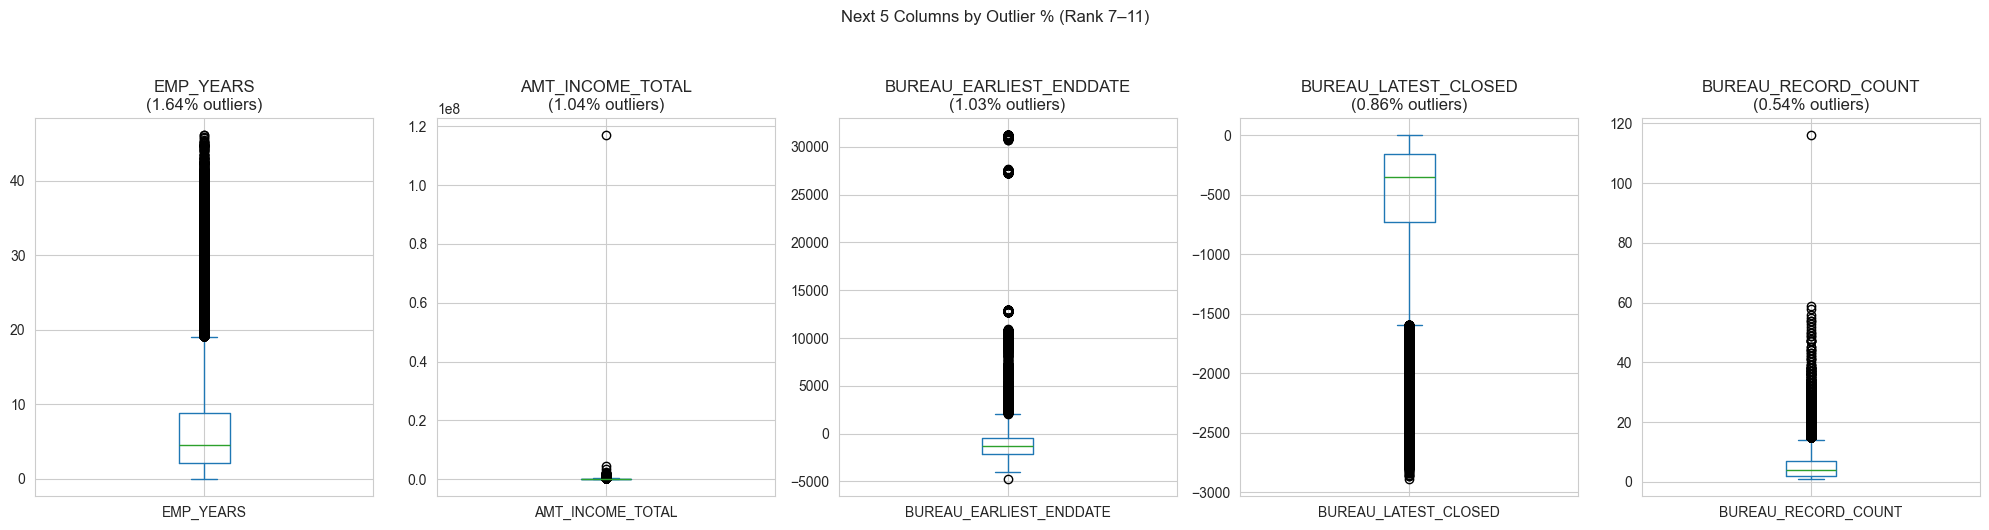

Next 5 columns: ['EMP_YEARS', 'AMT_INCOME_TOTAL', 'BUREAU_EARLIEST_ENDDATE', 'BUREAU_LATEST_CLOSED', 'BUREAU_RECORD_COUNT']


In [327]:
# Box-plots for next 5 outlier columns (rank 7–11)
next5 = outlier_df.iloc[6:11]['column'].tolist()

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(next5):
    ax = axes[i]
    merged_df_reduced[col].dropna().plot(kind='box', ax=ax)
    pct = outlier_df.loc[outlier_df['column'] == col, 'outlier_pct'].values[0]
    ax.set_title(f'{col}\n({pct}% outliers)')

plt.suptitle('Next 5 Columns by Outlier % (Rank 7–11)', y=1.05)
plt.tight_layout()
plt.show()

print("Next 5 columns:", next5)

In [328]:
# for i in next5:
    # print(f"\nValue counts for {i}:")
    # print("Head:")
    # # print(merged_df_reduced[i].value_counts(dropna=False).head(10))
    # print(merged_df_reduced[i].sort_values(ascending=False).head(10))
    # print("Tail:")
    # # print(merged_df_reduced[i].sort_values(ascending=True).head(10))
    # print(f"\nSummary stats for {i}:")

In [329]:
def check(col):
    # 1. Summary
    display(merged_df_reduced[col].describe(percentiles=[0.01,0.05,0.95,0.99]))

    # 2. Missing
    print(merged_df_reduced[col].isna().mean())

    # 3. Extremes
    display(merged_df_reduced[col].sort_values().head(10))
    display(merged_df_reduced[col].sort_values(ascending=False).head(10))

    # 4. Distribution
    merged_df_reduced[col].hist(bins=50)

    # 5. Target relationship
    display(merged_df_reduced.groupby(pd.qcut(merged_df_reduced[col], 10, duplicates='drop'))['TARGET'].mean())


In [330]:
# Outlier 1: EMP_YEARS
# check("EMP_YEARS")

# Right skewed but no significant outliers, keep as is for now


In [331]:
# Outlier 2: AMT_Income_Total

print(merged_df_reduced['AMT_INCOME_TOTAL'].sort_values(ascending=False).head(10))
# merged_df_reduced['AMT_INCOME_TOTAL'].hist(bins=50)

# There is a single extreme outlier at 117000000 that is much higher than the next highest value of 4500000.00. This is likely a data error. Replace with NaN.
merged_df_reduced.loc[merged_df_reduced['AMT_INCOME_TOTAL'] == 117000000, 'AMT_INCOME_TOTAL'] = np.nan
# print(merged_df_reduced['AMT_INCOME_TOTAL'].sort_values(ascending=False).head(10))

7294     117000000.00
115560     4500000.00
46782      3375000.00
116832     2250000.00
65020      2160000.00
22360      2025000.00
970        1935000.00
90230      1890000.00
117374     1800000.00
112108     1800000.00
Name: AMT_INCOME_TOTAL, dtype: float64


In [332]:
#outlier 3: BUREAU_EARLIEST_ENDDATE
# check("BUREAU_EARLIEST_ENDDATE")

# 99th percentile ≈ 4,883
# Max = 31,198
# There is a huge jump after the 99th percentile
# Values between ~5k and ~30k are extremely sparse, likely not part of the natural distribution

# 10,000 days ≈ 27 years
# 31,000 days ≈ 85 years
# 27 years → already very extreme but still borderline plausible
# 85 years → clearly impossible / data error

# 1. Treat extreme positive values as invalid (data errors => missing)
merged_df_reduced[col] = merged_df_reduced[col].mask(merged_df_reduced[col] > 10000)

# 2. Robust truncation for valid values (IQR method)
Q1 = merged_df_reduced[col].quantile(0.25)
Q3 = merged_df_reduced[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

merged_df_reduced[col] = merged_df_reduced[col].clip(lower, upper)




In [333]:
# Outlier 4: BUREAU_LATEST_CLOSED
col = "BUREAU_LATEST_CLOSED"
# merged_df_reduced[col].hist(bins=50)
# left skewed with a long right tail, but no significant outliers. keep as is for now

In [334]:
# Outlier 5: bureau_record_count
# merged_df_reduced['BUREAU_RECORD_COUNT'].sort_values(ascending=False).head(10)
# merged_df_reduced['BUREAU_RECORD_COUNT'].hist(bins=50)  
# there is a single outlier at 116 that is much higher than the next highest value of 59. This is likely a data error. Replace with NaN.
merged_df_reduced.loc[merged_df_reduced['BUREAU_RECORD_COUNT'] == 116, 'BUREAU_RECORD_COUNT'] = np.nan
# merged_df_reduced['BUREAU_RECORD_COUNT'].sort_values(ascending=False).head(10)

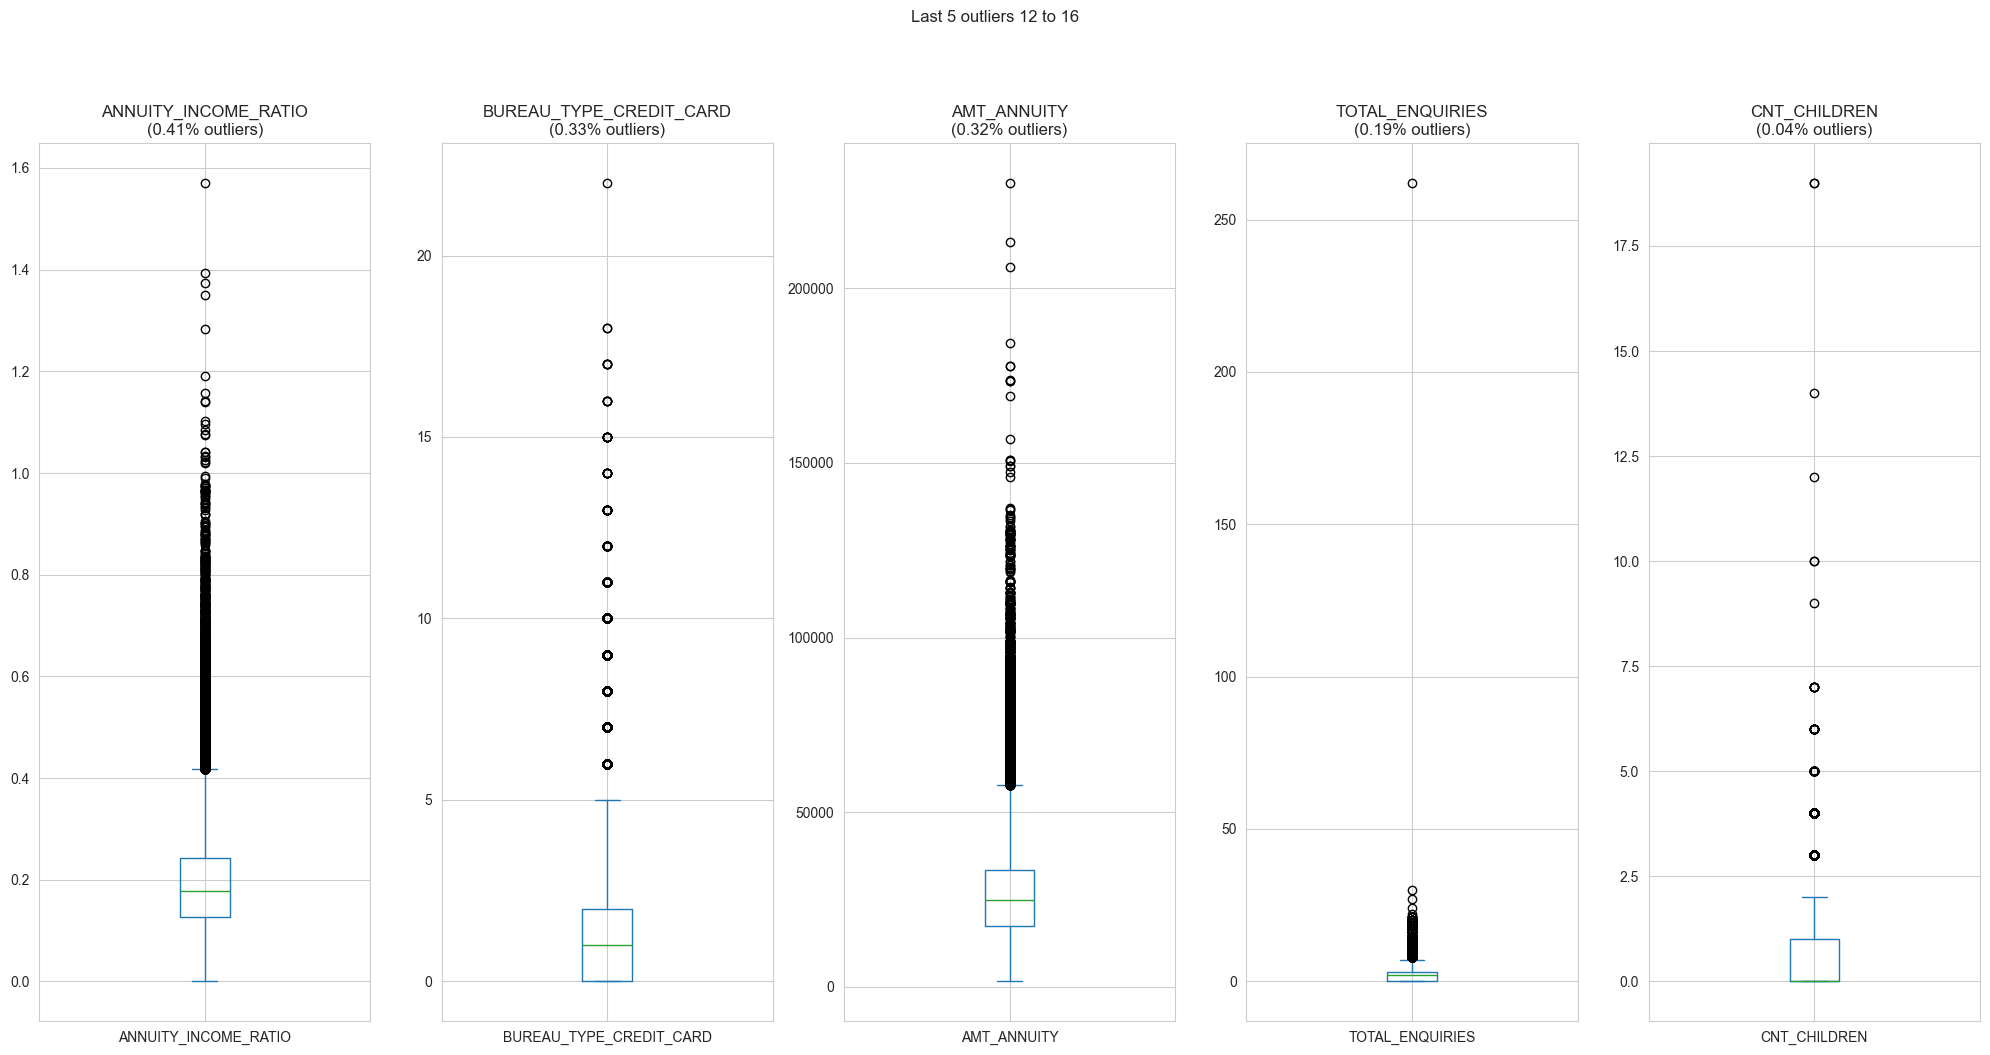

Outliers 12 to 16: ['ANNUITY_INCOME_RATIO', 'BUREAU_TYPE_CREDIT_CARD', 'AMT_ANNUITY', 'TOTAL_ENQUIRIES', 'CNT_CHILDREN']


In [335]:
# Take a look at the last 5 outliers from rank 12 to 16 in order
# 12 ANNUITY_INCOME_RATIO 
# 13 BUREAU_TYPE_CREDIT_CARD
# 14 AMT_ANNUIT
# 15 TOTAL_ENQUIRIES
# 16 CNT_CHILDREN

# Start with basic box plot visualisation to check for all 5 to see how it look
# Box plot for last 5 outliers 12 to 16
outliers_12_to_16 = outlier_df.iloc[11:16]['column'].tolist()
fig, axes = plt.subplots(1, 5, figsize=(20, 10))
for i, col in enumerate(outliers_12_to_16):
    ax = axes[i]
    merged_df_reduced[col].dropna().plot(kind='box', ax=ax)
    pct = outlier_df.loc[outlier_df['column'] == col, 'outlier_pct'].values[0]
    ax.set_title(f'{col}\n({pct}% outliers)')

plt.suptitle('Last 5 outliers 12 to 16', y=1.05)
plt.tight_layout()
plt.show()

print("Outliers 12 to 16:", outliers_12_to_16)

General Notes
1. For ANNUITY_INCOME_RATIO, can logically say that by right no lender will be willing to lend money to someone if 100% or more of their income goes towards repaying the loan.
    - But we cant just throw them away as there are some legit resons and scenarios where this makes sense: 
        - You have a fresh grad with low income applying for a loan and their parents are helping to pay part of the annuity
        - You have someone who has a lot of assets or side seasonal income that retired and declare only the money from the pension fund

2. For BUREAU_TYPE_CREDIT_CARD, it is technically possible for someone to own 10 or even 20 over credit cards

3. For AMT_ANNUITY, it does make sense if the value is very high if the income of the person is also in the high range 

4. TOTAL_ENQUIRIES, xan generally see that it stands out from the rest of them with a single outlier clearly going beyond 200 when the rest is lower than 90.

- 


In [336]:
# More investigation on outlier 12 - ANNUITY_INCOME_RATIO
merged_df_reduced['ratio_bin'] = pd.cut(merged_df_reduced['ANNUITY_INCOME_RATIO'],
    bins  = [0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.59, 0.75, 1.00, 1.20, float('inf')],
    labels = ['0-0.05', '0.05-0.10', '0.10-0.15', '0.15-0.20', '0.20-0.25',
          '0.25-0.30', '0.30-0.40', '0.40-0.50', '0.50-0.59',
          '0.59-0.75', '0.75-1.00', '1.00-1.20', '1.20+'])

bin_summary = merged_df_reduced.groupby('ratio_bin')['TARGET'].agg(['mean', 'count']).rename(
    columns={'mean': 'default_rate', 'count': 'n'})
display(bin_summary)

merged_df_reduced[merged_df_reduced['ANNUITY_INCOME_RATIO'] > 1][
    ['SK_ID_CURR', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL', 
     'ANNUITY_INCOME_RATIO', 'TARGET']
].sort_values('ANNUITY_INCOME_RATIO', ascending=False)

# display(merged_df_reduced['ANNUITY_INCOME_RATIO'].describe(percentiles=[0.01,0.05,0.95,0.99]))



,default_rate,n
ratio_bin,,
0-0.05,0.08,2623
0.05-0.10,0.08,21111
0.10-0.15,0.09,40048
0.15-0.20,0.09,40459
0.20-0.25,0.09,29607
0.25-0.30,0.10,18344
0.30-0.40,0.08,15914
0.40-0.50,0.09,3740
0.50-0.59,0.08,1070


,SK_ID_CURR,AMT_ANNUITY,AMT_INCOME_TOTAL,ANNUITY_INCOME_RATIO,TARGET
111654,329192,70677.00,45000.00,1.57,0
127769,361920,62698.50,45000.00,1.39,1
378,100784,74191.50,54000.00,1.37,1
116129,338291,48627.00,36000.00,1.35,1
113512,332872,51948.00,40500.00,1.28,0
36369,174612,64260.00,54000.00,1.19,0
150824,409321,31261.50,27000.00,1.16,0
93963,293005,33394.50,29250.00,1.14,0
14586,129999,52452.00,46044.00,1.14,0
63542,230424,44635.50,40500.00,1.10,0


For the outlier 12 - ANNUITY_INCOME_RATIO
- Seems like default rate is more or less flat from 0 to 1, outlier area seems to not be that meaningful for a predictive signal
- The 60% default rate at 1.2+ is only for 5 rows so not useful or reliable
- Does not look like there are any glaring errors or issues based on the values of the AMT_ANNUITY and AMT_INCOME_TOTAL for the 5 extreme rows
<br><br>

Action to be taken
    - Will cap the values to 99th percentile at 0.5037 to handle the extremes 



In [337]:
merged_df_reduced.drop(columns=['ratio_bin'], inplace=True)

cap_99 = merged_df_reduced['ANNUITY_INCOME_RATIO'].quantile(0.99)
print(f"Capping ANNUITY_INCOME_RATIO at {cap_99:.4f}")

merged_df_reduced['ANNUITY_INCOME_RATIO'] = merged_df_reduced['ANNUITY_INCOME_RATIO'].clip(upper=cap_99)

Capping ANNUITY_INCOME_RATIO at 0.5037


In [338]:
# More investigation on outlier 13 - BUREAU_TYPE_CREDIT_CARD
summary = merged_df_reduced.groupby('BUREAU_TYPE_CREDIT_CARD')['TARGET'].agg(
    default_rate='mean',
    count='count'
).reset_index()

print(summary.to_string())

# Check the extreme rows
merged_df_reduced[merged_df_reduced['BUREAU_TYPE_CREDIT_CARD'] > 12][
    ['SK_ID_CURR', 'BUREAU_TYPE_CREDIT_CARD', 'TARGET']
].sort_values('BUREAU_TYPE_CREDIT_CARD', ascending=False).head(20)

# display(merged_df_reduced['BUREAU_TYPE_CREDIT_CARD'].describe(percentiles=[0.01,0.05,0.95,0.99]))

    BUREAU_TYPE_CREDIT_CARD  default_rate  count
0                      0.00          0.08  51160
1                      1.00          0.08  48313
2                      2.00          0.09  24304
3                      3.00          0.10  11585
4                      4.00          0.10   5627
5                      5.00          0.11   2773
6                      6.00          0.11   1447
7                      7.00          0.11    703
8                      8.00          0.14    365
9                      9.00          0.15    202
10                    10.00          0.16    129
11                    11.00          0.16     76
12                    12.00          0.19     31
13                    13.00          0.29     17
14                    14.00          0.71      7
15                    15.00          0.25      8
16                    16.00          0.25      4
17                    17.00          0.25      4
18                    18.00          0.00      2
19                  

,SK_ID_CURR,BUREAU_TYPE_CREDIT_CARD,TARGET
135004,376667,22.00,0
163263,434896,18.00,0
22382,145911,18.00,0
170968,450684,17.00,0
103014,311508,17.00,1
31305,164261,17.00,0
146601,400169,17.00,0
114311,334563,16.00,0
142777,392213,16.00,0
77766,259618,16.00,0


For the outlier 13 - BUREAU_TYPE_CREDIT_CARD
- Seems like there is monotonically increasing default rate from 0 cards 12 cards which does tell us that this does have real predictive signal, at 12 the count is very low at 31 so it could possible be noise as well
- Above 13 cards, counts drop sharply which makes it unreliable and noisy like in 14 where the rate jump up to 0.71
<br><br>

Action to be taken
    - Will cap the values at 10 to remove the noisy tail

In [339]:
print(f"Capping BUREAU_TYPE_CREDIT_CARD at 10")
merged_df_reduced['BUREAU_TYPE_CREDIT_CARD'] = merged_df_reduced['BUREAU_TYPE_CREDIT_CARD'].clip(upper=10)

Capping BUREAU_TYPE_CREDIT_CARD at 10


In [340]:
# More investigation on outlier 14 - AMT_ANNUITY
bins = [0, 10000, 20000, 30000, 45000, 60000, 80000, 
        100000, 150000, float('inf')]
labels = ['0-10k','10-20k','20-30k','30-45k','45-60k',
          '60-80k','80-100k','100-150k','150k+']

merged_df_reduced['annuity_bin'] = pd.cut(
    merged_df_reduced['AMT_ANNUITY'], bins=bins, labels=labels)

merged_df_reduced.groupby('annuity_bin', observed=True)['TARGET'].agg(
    default_rate='mean', count='count')


merged_df_reduced[merged_df_reduced['AMT_ANNUITY'] > 150000][
    ['SK_ID_CURR', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL', 
     'ANNUITY_INCOME_RATIO', 'TARGET']
].sort_values('AMT_ANNUITY', ascending=False)


# display(merged_df_reduced['AMT_ANNUITY'].describe(percentiles=[0.01,0.05,0.95,0.99]))

,SK_ID_CURR,AMT_ANNUITY,AMT_INCOME_TOTAL,ANNUITY_INCOME_RATIO,TARGET
57338,217854,230161.50,1575000.00,0.15,0
78975,262093,213291.00,720000.00,0.30,0
50399,203629,206167.50,427500.00,0.48,0
139238,385161,184477.50,675000.00,0.27,0
124462,355238,177826.50,427500.00,0.42,0
68864,241260,177696.00,427500.00,0.42,0
19432,139943,173704.50,270000.00,0.50,0
23607,148486,173574.00,225000.00,0.50,0
152650,413277,173574.00,445500.00,0.39,0
77219,258528,169231.50,675000.00,0.25,0


For the outlier 14 - AMT_ANNUITY
- Can see that efault rate decreases monotonically with higher annuity amounts. This does make sense as larger loans are only given to more creditworthy borrowers
- Above 80k counts drop off a cliff which makes rates in the extreme tail statistically unreliable
- Extreme values > 150000 checks out when looking at the AMT_INCOME_TOTAL and the ANNUITY_INCOME_RATIO, with all of them being GOOD, it seems reasonable. 
<br><br>

Action to be taken
    - Will cap the values at 99th percentile as the meaningful signal is still captured in the values below the cap

In [341]:
merged_df_reduced.drop(columns=['annuity_bin'], inplace=True)

cap_99 = merged_df_reduced['AMT_ANNUITY'].quantile(0.99)  # 68490
print(f"Capping AMT_ANNUITY at {cap_99:.4f}")
merged_df_reduced['AMT_ANNUITY'] = merged_df_reduced['AMT_ANNUITY'].clip(upper=cap_99)

Capping AMT_ANNUITY at 68490.0000


In [342]:
# More investigation on outlier 15 - TOTAL_ENQUIRIES
# Very obvious outlier above 200 when the rest are not even close
merged_df_reduced[merged_df_reduced['TOTAL_ENQUIRIES'] > 50][
    ['SK_ID_CURR', 'TOTAL_ENQUIRIES', 'TARGET']
].sort_values('TOTAL_ENQUIRIES', ascending=False).head(10)


display(merged_df_reduced['TOTAL_ENQUIRIES'].describe(percentiles=[0.01,0.05,0.95,0.99]))

merged_df_reduced['TOTAL_ENQUIRIES'].value_counts().sort_index(ascending=False).head(20)

summary = merged_df_reduced.groupby('TOTAL_ENQUIRIES')['TARGET'].agg(
    default_rate='mean', count='count'
).reset_index().sort_values('TOTAL_ENQUIRIES')

display(summary)


count   173647.00
mean         2.18
std          2.35
min          0.00
1%           0.00
5%           0.00
50%          2.00
95%          7.00
99%          9.00
max        262.00
Name: TOTAL_ENQUIRIES, dtype: float64

,TOTAL_ENQUIRIES,default_rate,count
0,0.00,0.10,52521
1,1.00,0.08,29481
2,2.00,0.09,28542
3,3.00,0.08,22232
4,4.00,0.09,15563
5,5.00,0.09,10118
6,6.00,0.09,6296
7,7.00,0.10,3870
8,8.00,0.09,2262
9,9.00,0.10,1350


For the outlier 15 - TOTAL_ENQUIRIES
- Single completely isolated extreme value of 262 when the next highest is 30, with a massive gap in between. The 99th percentile sits at just 9 which makes 262 almost 29× the 99th percentile
- Default rate seems completely flat at across all values from 0 to 11, no usful predictive signal seems to be present
    - Seems to go against the logic that someone who has more enquiries means they are more desperate for credit as they get rejected often
- Seems likely that the extreme of 262 is likely a error 


Action to be taken
    - Replace the single extreme value of 262 with nan
    - Will also cap the values at 99th percentile to cut the noise 

In [343]:
# Replace single extreme outlier with NaN
print(f"Replacing extreme outlier with NaN")
merged_df_reduced.loc[merged_df_reduced['TOTAL_ENQUIRIES'] > 30, 
                      'TOTAL_ENQUIRIES'] = np.nan

# Then cap remaining at 99th pct
cap_99 = merged_df_reduced['TOTAL_ENQUIRIES'].quantile(0.99)
print(f"Capping TOTAL_ENQUIRIES at {cap_99:.4f}")
merged_df_reduced['TOTAL_ENQUIRIES'] = merged_df_reduced['TOTAL_ENQUIRIES'].clip(upper=cap_99)

Replacing extreme outlier with NaN
Capping TOTAL_ENQUIRIES at 9.0000


In [349]:
# More investigation on outlier 16 - CNT_CHILDREN
summary = merged_df_reduced.groupby('CNT_CHILDREN')['TARGET'].agg(
    default_rate='mean', count='count'
).reset_index()

display(summary)


display(merged_df_reduced['CNT_CHILDREN'].describe(percentiles=[0.01,0.05,0.95,0.99]))


display(merged_df_reduced[merged_df_reduced['CNT_CHILDREN'] > 5][
    ['SK_ID_CURR', 'CNT_CHILDREN', 'AGE_YEARS', 'TARGET']
].sort_values('CNT_CHILDREN', ascending=False))

display(merged_df_reduced[merged_df_reduced['CNT_CHILDREN'] > 5][
    ['SK_ID_CURR', 'CNT_CHILDREN', 'NAME_FAMILY_STATUS', 'TARGET']
].sort_values('CNT_CHILDREN', ascending=False))

,CNT_CHILDREN,default_rate,count
0,0,0.08,127145
1,1,0.10,31468
2,2,0.11,12960
3,3,0.11,1784
4,4,0.13,223
5,5,0.05,41
6,6,0.46,13
7,7,0.00,6
8,9,1.00,1
9,10,0.00,2


count   173647.00
mean         0.37
std          0.69
min          0.00
1%           0.00
5%           0.00
50%          0.00
95%          2.00
99%          3.00
max         19.00
Name: CNT_CHILDREN, dtype: float64

,SK_ID_CURR,CNT_CHILDREN,AGE_YEARS,TARGET
150186,407877,19,28.20,0
87761,280108,19,30.30,0
151382,410527,14,42.30,0
45731,193853,12,38.60,0
105456,316580,10,41.20,0
74933,253779,10,31.40,0
13500,127782,9,29.90,1
1727,103596,7,48.40,0
132002,370590,7,48.20,0
124355,355015,7,37.90,0


,SK_ID_CURR,CNT_CHILDREN,NAME_FAMILY_STATUS,TARGET
150186,407877,19,Single / not married,0
87761,280108,19,Single / not married,0
151382,410527,14,Married,0
45731,193853,12,Married,0
105456,316580,10,Married,0
74933,253779,10,Married,0
13500,127782,9,Single / not married,1
1727,103596,7,Married,0
132002,370590,7,Married,0
124355,355015,7,Married,0


For the outlier 16 - CNT_CHILDREN
- Rising default rate from 0 (8%) to 4 children (13%) does show that there is real predictive signal in the lower ranges
- Number of records drops drastically at 5 and above, rates also jump all over the place
- There are also gaps as 8, 11, 13, 16, 17, 18 don't exist
- 99th percentile is only 3, so values above 5 are extreme outliers
- Logically also dosn't make sense for someone to have 19 children - especially if they are single, 6 or even 7 could be argued but 
- does not seem so isolated enough like TOTAL_ENQUIRIES, so no need to nan the 19s


Action to be taken
    - Will cap the values at 5 to preserve the 0 - 4 signal while addressing the problemetic tail 

In [350]:
print(f"Capping CNT_CHILDREN at 5")
merged_df_reduced['CNT_CHILDREN'] = merged_df_reduced['CNT_CHILDREN'].clip(upper=5)


Capping CNT_CHILDREN at 5
